# Análisis de Supervivencia No Paramétrico — Kaplan-Meier
## Estudio de la supervivencia empresarial

Dataset combinado: **train + test** — análisis unificado de toda la muestra.


## 1. Configuración e imports

In [82]:
import os, sys, warnings, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import survival_analysis as sa

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)


## 2. Carga de datos

### 2.1 Counting-process → colapsado

Los datos fuente están en formato *counting-process* (múltiples filas por empresa). Se colapsan a una única fila por empresa tomando la primera observación cronológica como referencia basal. El tiempo de vida se calcula como:

$$
\text{tiempo} =
\begin{cases}
\text{Stop}_{\text{evento}} - \min(\text{Start}) & \text{si evento ocurre} \\
\max(\text{Stop}) - \min(\text{Start}) & \text{si censurado}
\end{cases}
$$


In [83]:
TRAIN_PATH  = '/media/datos/WORKSPACE/DOCTORADO/datasets/train_set.csv'
TEST_PATH   = '/media/datos/WORKSPACE/DOCTORADO/datasets/test_set.csv'
TRAIN_COLLAPSED  = 'datasets/train_collapsed.csv'
TEST_COLLAPSED   = 'datasets/test_collapsed.csv'
COMBINED_COLLAPSED = 'datasets/all_collapsed.csv'

def load_collapsed():
    if os.path.exists(COMBINED_COLLAPSED):
        return pd.read_csv(COMBINED_COLLAPSED)
    train_c = pd.read_csv(TRAIN_COLLAPSED) if os.path.exists(TRAIN_COLLAPSED) else None
    test_c  = pd.read_csv(TEST_COLLAPSED)  if os.path.exists(TEST_COLLAPSED)  else None
    if train_c is None or test_c is None:
        raw_train = pd.read_csv(TRAIN_PATH)
        raw_test  = pd.read_csv(TEST_PATH)
        def _collapse(df):
            df = df.sort_values(['CIF','Start']).reset_index(drop=True)
            cov = [c for c in df.columns if c not in ('CIF','Start','Stop','Event')]
            bsl  = df.groupby('CIF')[cov].nth(0).reset_index()
            t0   = df.groupby('CIF')['Start'].min()
            tN   = df.groupby('CIF')['Stop'].max()
            evt  = df.groupby('CIF')['Event'].max()
            time = tN - t0
            ev_stop = df[df['Event']==1].groupby('CIF')['Stop'].max()
            ev_cifs = ev_stop.index.intersection(time.index)
            time[ev_cifs] = ev_stop[ev_cifs] - t0[ev_cifs]
            out = bsl.copy()
            out['Start'] = 0
            out['Stop']  = time.values
            out['Event'] = evt.values.astype(int)
            return out
        train_c = _collapse(raw_train); train_c.to_csv(TRAIN_COLLAPSED, index=False)
        test_c  = _collapse(raw_test);  test_c.to_csv(TEST_COLLAPSED, index=False)
    combined = pd.concat([
        train_c.assign(dataset='TRAIN'),
        test_c.assign(dataset='TEST'),
    ], ignore_index=True)
    combined.to_csv(COMBINED_COLLAPSED, index=False)
    return combined

all_data = load_collapsed()
print(f'Dataset combinado: {len(all_data):,} empresas')
print(f'  Train: {(all_data["dataset"]=="TRAIN").sum():,}')
print(f'  Test:  {(all_data["dataset"]=="TEST").sum():,}')
print(f'  Eventos: {int(all_data["Event"].sum()):,} ({all_data["Event"].mean()*100:.1f}%)')
all_data.head(3)


Dataset combinado: 117,052 empresas
  Train: 93,641
  Test:  23,411
  Eventos: 47,752 (40.8%)


,CIF,N1,N2,N3_Agriculture,N3_Construction,N3_Industry,N3_nan,N3_Services,N4_Cooperative,N4_Limited Company,...,F38,F39,F40,F41,F42,F43,Start,Stop,Event,dataset
0,A01000090,-2.087666,-1.610883,0,0,1,0,0,0,0,...,-0.000758,-0.000843,-0.000655,-0.000155,0.000461,0.000258,0,21,0,TRAIN
1,A01000652,-2.087666,-1.610883,0,0,0,0,1,0,0,...,-0.000739,-0.000965,-0.000596,-0.000154,0.000335,0.000217,0,22,0,TRAIN
2,A01001007,2.803063,-1.610883,0,0,1,0,0,0,0,...,-0.000749,-0.000403,-0.000636,-0.000152,0.000364,0.000232,0,7,0,TRAIN


## 3. Estadísticas descriptivas

In [84]:
n = len(all_data)
ne = int(all_data['Event'].sum())
print(f'Total empresas:        {n:>8,}')
print(f'Eventos (insolvencia): {ne:>8,} ({ne/n*100:.2f}%)')
print(f'Censurados:            {n-ne:>8,} ({(n-ne)/n*100:.2f}%)')
print()
print('Distribución del tiempo de supervivencia (años):')
print(all_data['Stop'].describe())


Total empresas:         117,052
Eventos (insolvencia):   47,752 (40.80%)
Censurados:              69,300 (59.20%)

Distribución del tiempo de supervivencia (años):
count    117052.000000
mean         14.092660
std           7.050403
min           1.000000
25%           8.000000
50%          15.000000
75%          22.000000
max          22.000000
Name: Stop, dtype: float64


## 4. Función de supervivencia global

Estimación Kaplan-Meier con intervalo de confianza al 95%. Se marca el umbral de riesgo en S(t)=0.5 y el año de cruce.

In [85]:
kmf_g = KaplanMeierFitter()
kmf_g.fit(durations=all_data['Stop'], event_observed=all_data['Event'],
          entry=all_data['Start'], label='Global')

med = kmf_g.median_survival_time_
print(f'Mediana de supervivencia: {med:.1f} años' if np.isfinite(med) else 'Mediana: No alcanzada')
print()
for t in [1,2,3,5,10,15,20]:
    try:
        s = kmf_g.survival_function_at_times(t)
        print(f'S(t={t:<2d}) = {s.iloc[0] if hasattr(s,"iloc") else float(s):.4f}')
    except: pass


Mediana: No alcanzada

S(t=1 ) = 0.9789
S(t=2 ) = 0.9450
S(t=3 ) = 0.9215
S(t=5 ) = 0.8733
S(t=10) = 0.7484
S(t=15) = 0.6066
S(t=20) = 0.5507


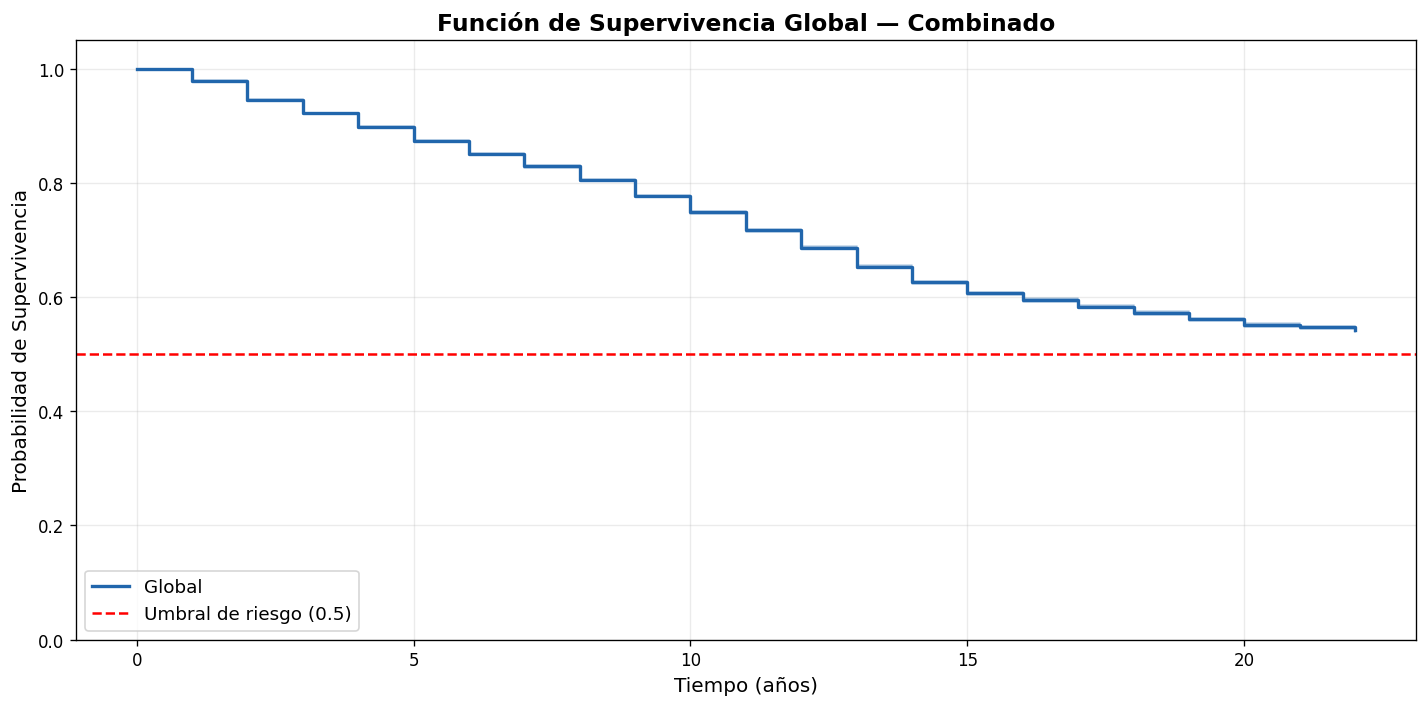

In [86]:
fig, ax = plt.subplots()
kmf_g.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color='#2166ac')
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')

sf = kmf_g.survival_function_
mask = sf.iloc[:,0] < 0.5
if mask.any():
    tc = sf.index[mask.values.argmax()]
    ax.axvline(x=tc, color='#2166ac', linestyle='--', linewidth=1.5)
    ax.text(tc, 0.95, f'{tc:.0f}', color='#2166ac', fontsize=11, ha='center', va='top',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='#2166ac', alpha=0.8))

ax.set_title('Función de Supervivencia Global — Combinado', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12)
ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=11, loc='lower left')
plt.tight_layout(); plt.show()


## 5. Análisis por variables categóricas

Para cada variable categórica se estiman curvas de supervivencia por grupo y se comparan mediante el test de log-rank (multi-grupo).

### 5.1 N3_Sector

In [87]:
categories = sa.resolve_category(all_data, ['N3_Agriculture', 'N3_Construction', 'N3_Industry', 'N3_Services'], ['Agricultura', 'Construccion', 'Industria', 'Servicios'])
present = [l for l in ['Agricultura', 'Construccion', 'Industria', 'Servicios'] if categories.eq(l).any()]
fitters = {}
for label in present:
    mask = categories == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: N3_Sector')
for lbl, kmf in fitters.items():
    n  = int((categories==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:30s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = categories.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], categories[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: N3_Sector
  Agricultura                    n= 1,370  eventos=  521  mediana=No alcanzada
  Construccion                   n=37,901  eventos=14,638  mediana=No alcanzada
  Industria                      n=21,856  eventos=9,528  mediana=No alcanzada
  Servicios                      n=55,925  eventos=23,065  mediana=No alcanzada

Log-rank p = 7.51e-01


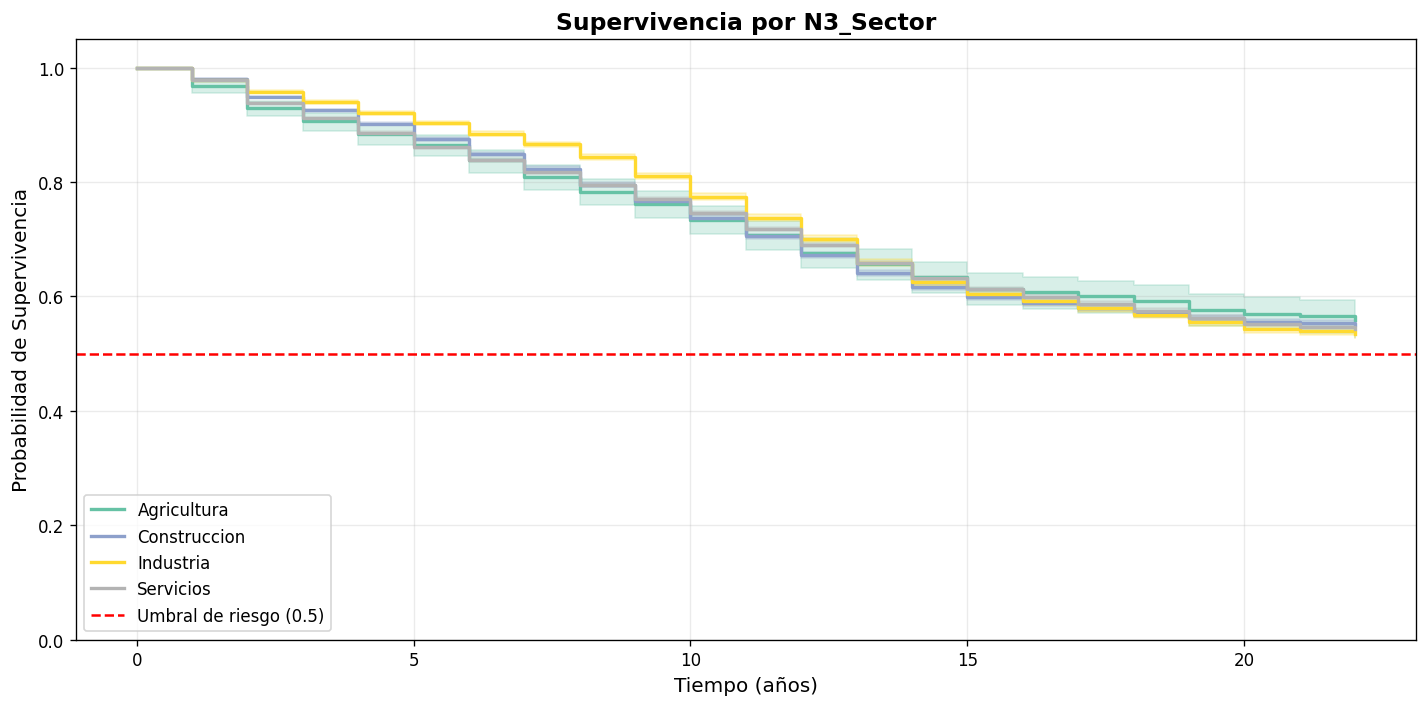

In [88]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por N3_Sector', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 5.2 N4_LegalForm

In [89]:
categories = sa.resolve_category(all_data, ['N4_Cooperative', 'N4_Limited Company'], ['Cooperativa', 'S.L.'])
present = [l for l in ['Cooperativa', 'S.L.'] if categories.eq(l).any()]
fitters = {}
for label in present:
    mask = categories == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: N4_LegalForm')
for lbl, kmf in fitters.items():
    n  = int((categories==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:30s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = categories.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], categories[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: N4_LegalForm
  Cooperativa                    n=   135  eventos=   68  mediana=11.0
  S.L.                           n=94,370  eventos=38,665  mediana=No alcanzada

Log-rank p = 8.70e-13


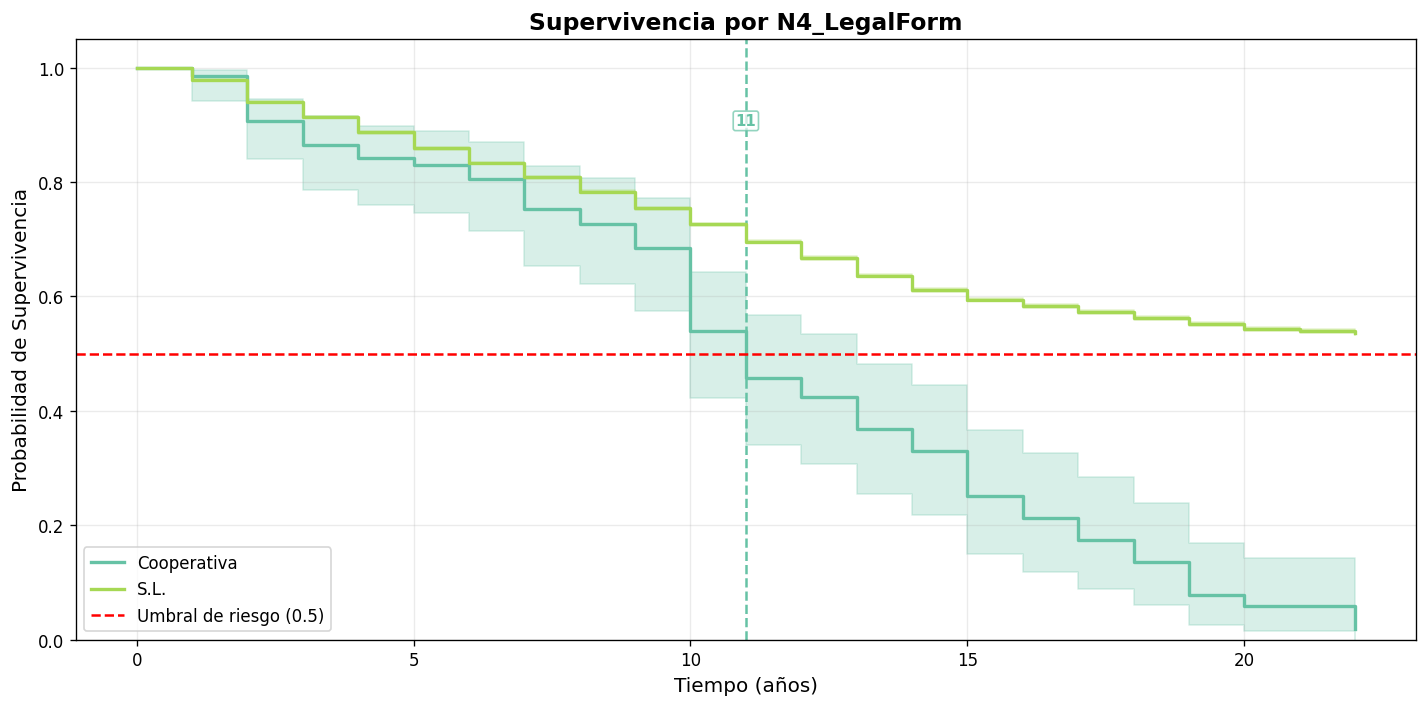

In [90]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por N4_LegalForm', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 5.3 N5

In [91]:
categories = sa.resolve_category(all_data, ['N5_No', 'N5_Yes'], ['No', 'Si'])
present = [l for l in ['No', 'Si'] if categories.eq(l).any()]
fitters = {}
for label in present:
    mask = categories == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: N5')
for lbl, kmf in fitters.items():
    n  = int((categories==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:30s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = categories.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], categories[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: N5
  No                             n=109,761  eventos=44,878  mediana=No alcanzada
  Si                             n= 7,291  eventos=2,874  mediana=No alcanzada

Log-rank p = 5.81e-26


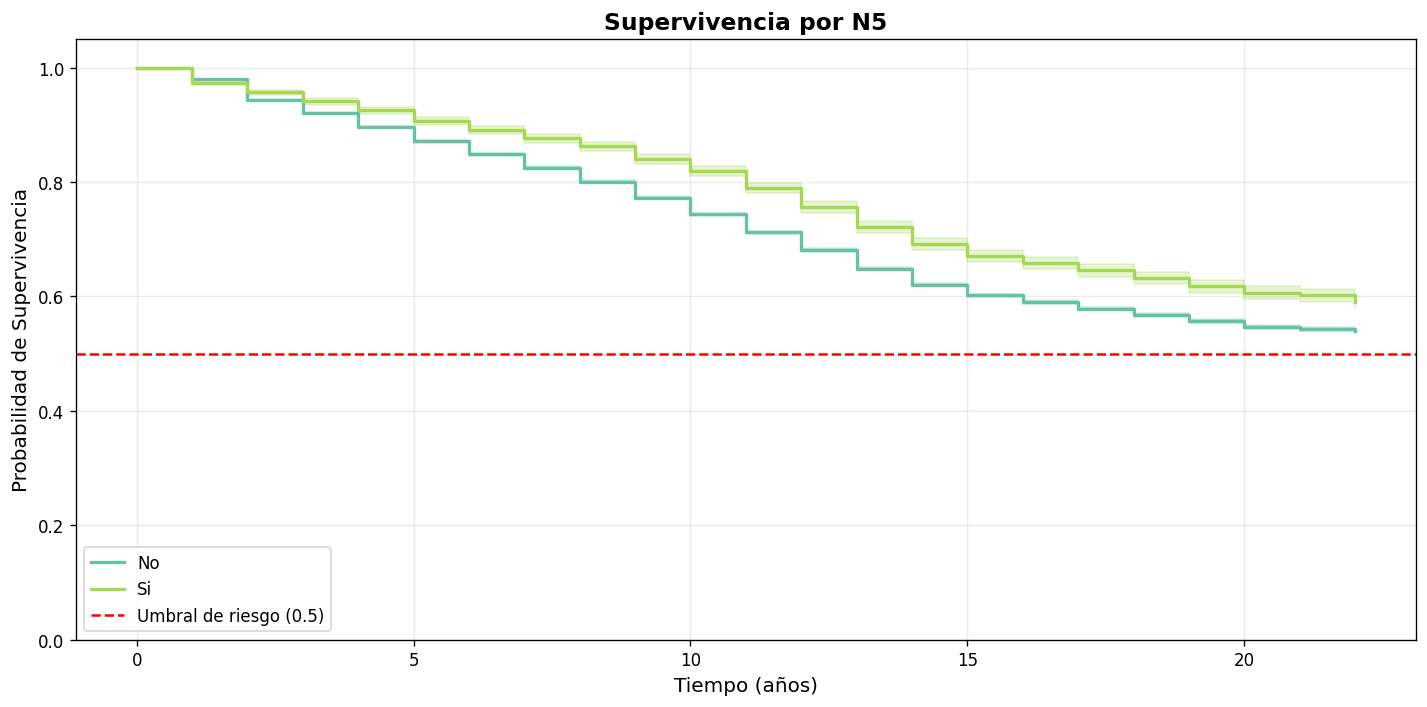

In [92]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por N5', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 5.4 N8_Size

In [93]:
categories = sa.resolve_category(all_data, ['N8_Microenterprise', 'N8_Small company', 'N8_Medium enterprise'], ['Microempresa', 'Pequeña', 'Mediana'])
present = [l for l in ['Microempresa', 'Pequeña', 'Mediana'] if categories.eq(l).any()]
fitters = {}
for label in present:
    mask = categories == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: N8_Size')
for lbl, kmf in fitters.items():
    n  = int((categories==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:30s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = categories.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], categories[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: N8_Size
  Microempresa                   n=70,623  eventos=27,657  mediana=No alcanzada
  Pequeña                        n=37,542  eventos=16,179  mediana=No alcanzada
  Mediana                        n= 8,887  eventos=3,916  mediana=No alcanzada

Log-rank p = 2.99e-01


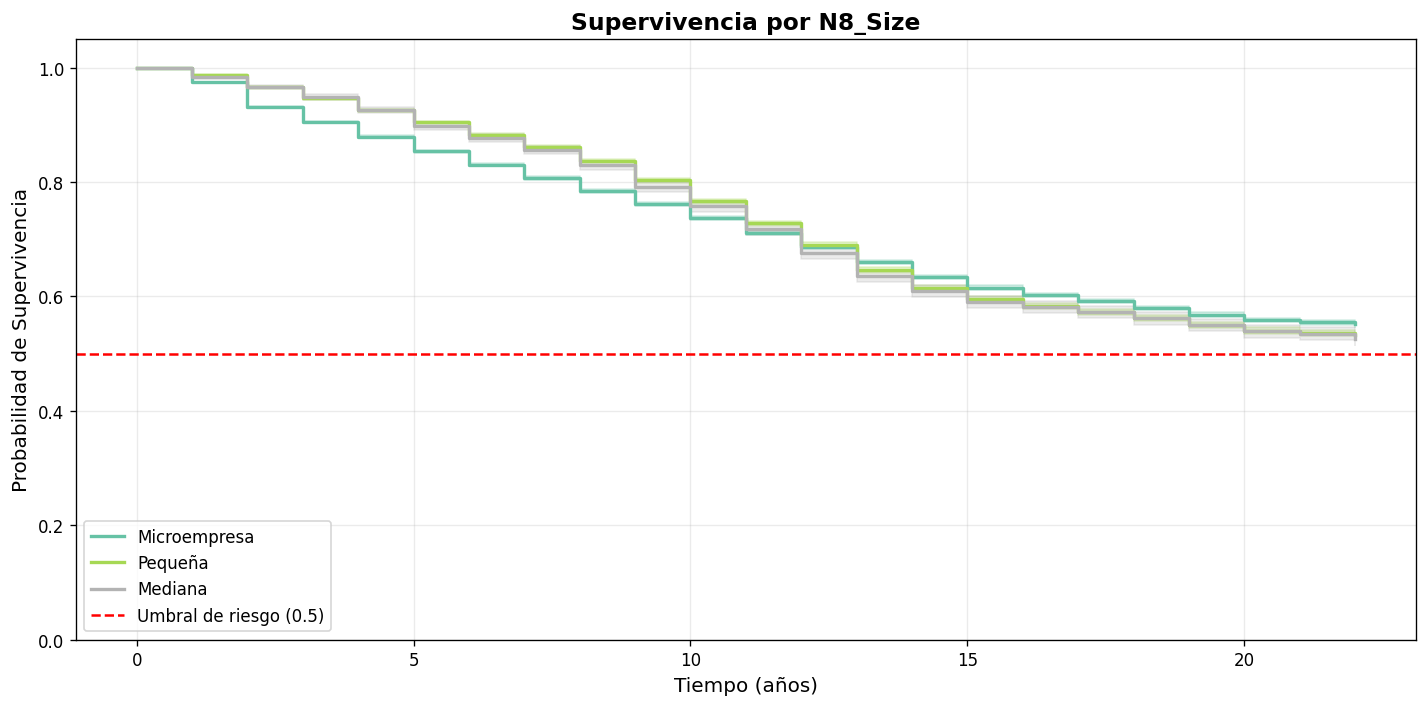

In [94]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por N8_Size', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 5.5 N9

In [95]:
categories = sa.resolve_category(all_data, ['N9_No', 'N9_Yes'], ['No', 'Si'])
present = [l for l in ['No', 'Si'] if categories.eq(l).any()]
fitters = {}
for label in present:
    mask = categories == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: N9')
for lbl, kmf in fitters.items():
    n  = int((categories==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:30s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = categories.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], categories[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: N9
  No                             n=116,066  eventos=46,922  mediana=No alcanzada
  Si                             n=   986  eventos=  830  mediana=5.0

Log-rank p = 0.00e+00


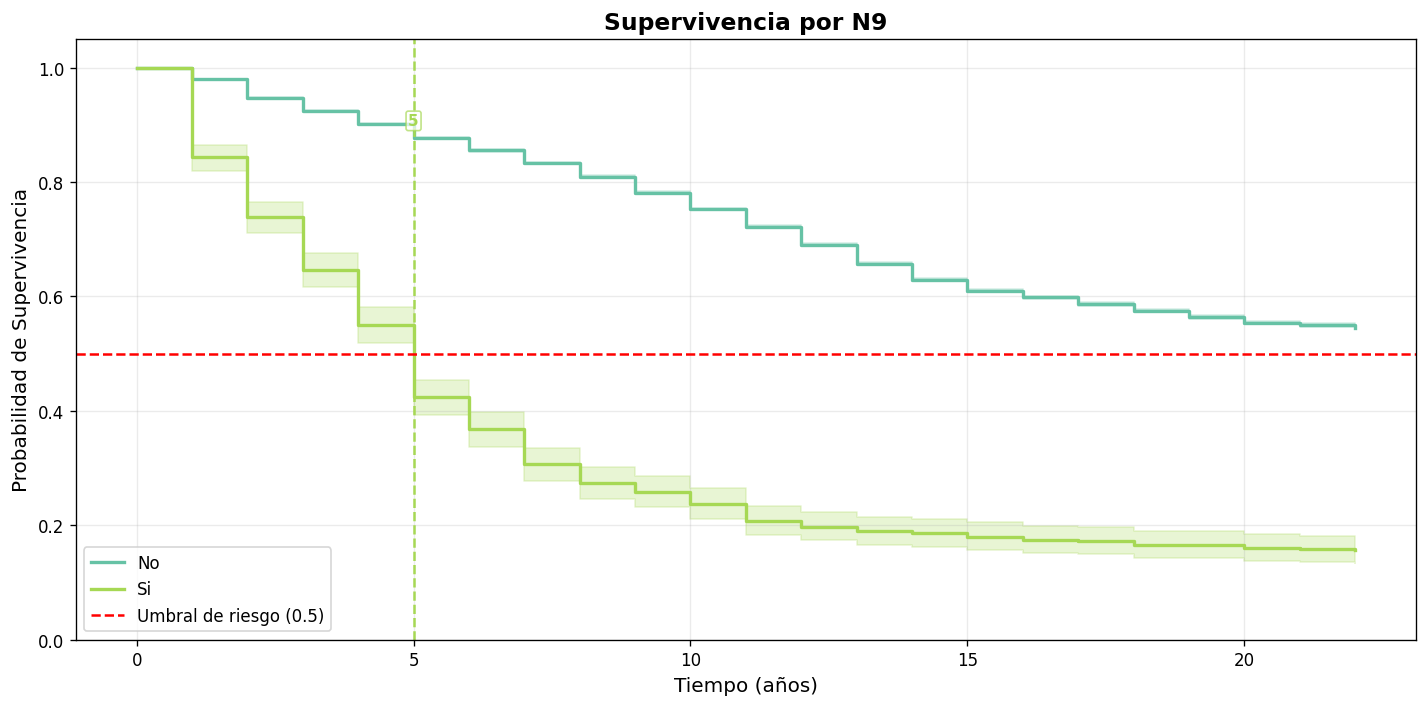

In [96]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por N9', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 5.6 N10_AuditOpinion

In [97]:
categories = sa.resolve_category(all_data, ['N10_Favorable', 'N10_Qualified', 'N10_Unfavorable'], ['Favorable', 'Con salvedades', 'Desfavorable'])
present = [l for l in ['Favorable', 'Con salvedades', 'Desfavorable'] if categories.eq(l).any()]
fitters = {}
for label in present:
    mask = categories == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: N10_AuditOpinion')
for lbl, kmf in fitters.items():
    n  = int((categories==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:30s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = categories.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], categories[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: N10_AuditOpinion
  Favorable                      n=   534  eventos=  423  mediana=5.0
  Con salvedades                 n=   394  eventos=  353  mediana=5.0
  Desfavorable                   n=     6  eventos=    6  mediana=2.0

Log-rank p = 3.45e-03


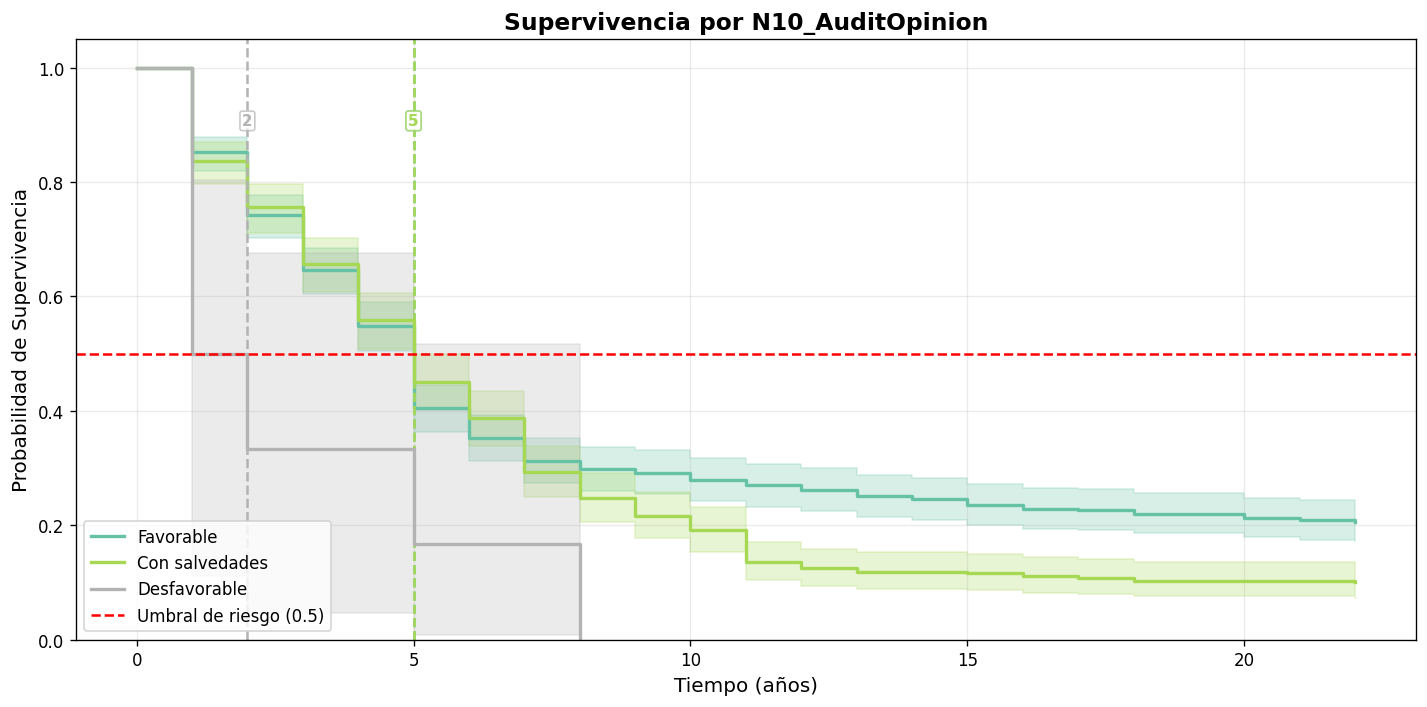

In [98]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por N10_AuditOpinion', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 5.7 N11

In [99]:
categories = sa.resolve_category(all_data, ['N11_Female', 'N11_Male'], ['Femenino', 'Masculino'])
present = [l for l in ['Femenino', 'Masculino'] if categories.eq(l).any()]
fitters = {}
for label in present:
    mask = categories == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: N11')
for lbl, kmf in fitters.items():
    n  = int((categories==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:30s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = categories.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], categories[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: N11
  Femenino                       n=10,725  eventos=1,492  mediana=No alcanzada
  Masculino                      n=57,117  eventos=10,309  mediana=No alcanzada

Log-rank p = 7.44e-26


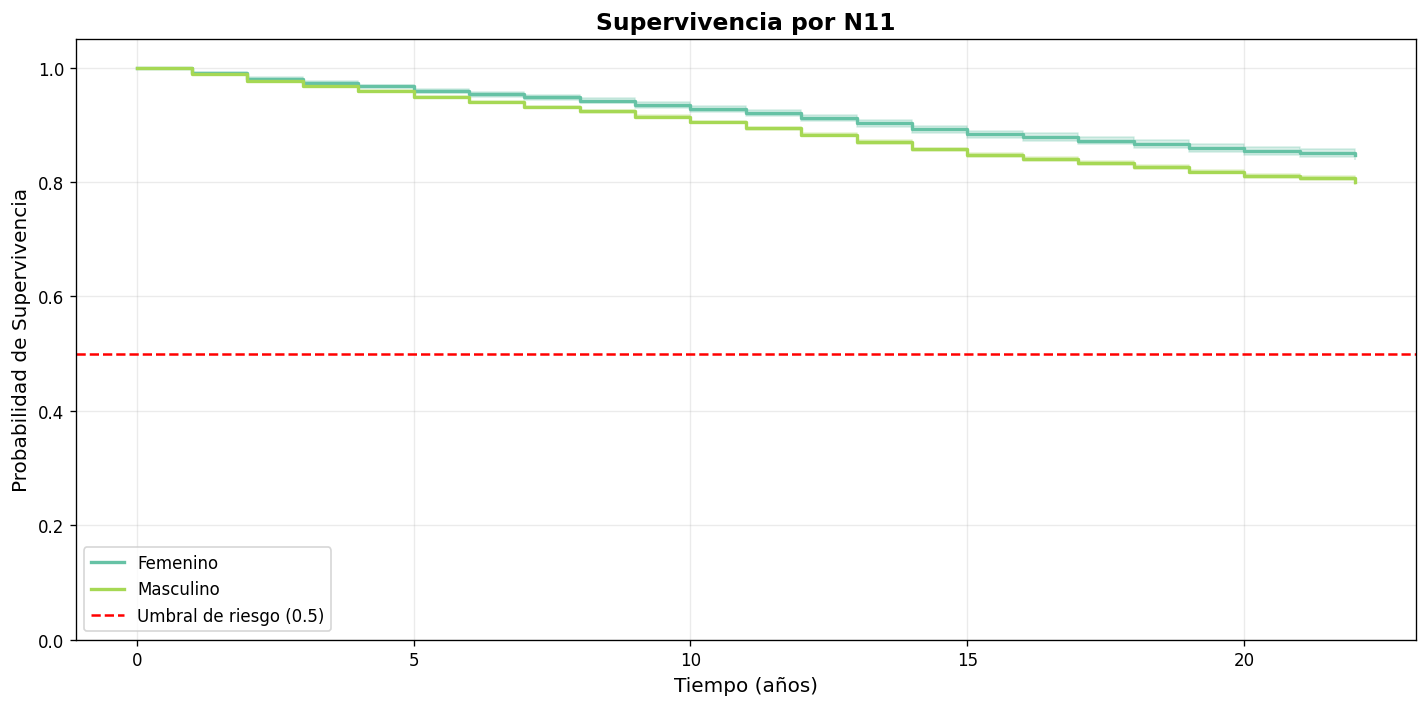

In [100]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por N11', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 5.8 N15

In [101]:
categories = sa.resolve_category(all_data, ['N15_No', 'N15_Yes'], ['No', 'Si'])
present = [l for l in ['No', 'Si'] if categories.eq(l).any()]
fitters = {}
for label in present:
    mask = categories == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: N15')
for lbl, kmf in fitters.items():
    n  = int((categories==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:30s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = categories.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], categories[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: N15
  No                             n=97,099  eventos=45,879  mediana=18.0
  Si                             n=19,953  eventos=1,873  mediana=No alcanzada

Log-rank p = 0.00e+00


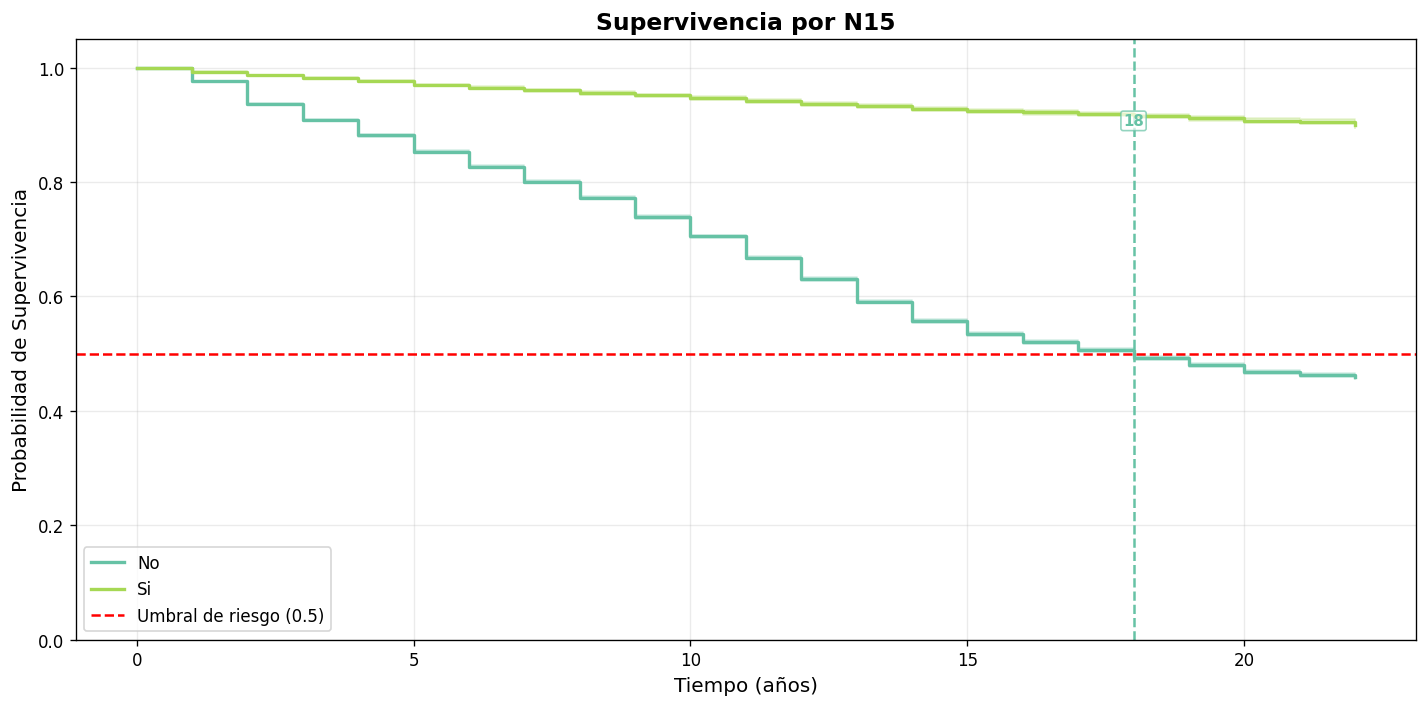

In [102]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por N15', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


## 6. Análisis por variables numéricas (mediana)

Cada variable numérica se divide en dos grupos por la mediana y se comparan las curvas de supervivencia. El test de log-rank evalúa si las diferencias entre grupos son significativas.

### 6.1 N1

In [103]:
groups = pd.cut(all_data['N1'], bins=[-np.inf, -1.6225968291511987, np.inf], labels=['≤-1.622597', '>-1.622597'], include_lowest=True)
present = [l for l in ['≤-1.622597', '>-1.622597'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: N1')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: N1
  ≤-1.622597                n=60,447  eventos=20,300  mediana=No alcanzada
  >-1.622597                n=56,605  eventos=27,452  mediana=18.0

Log-rank p = 0.00e+00


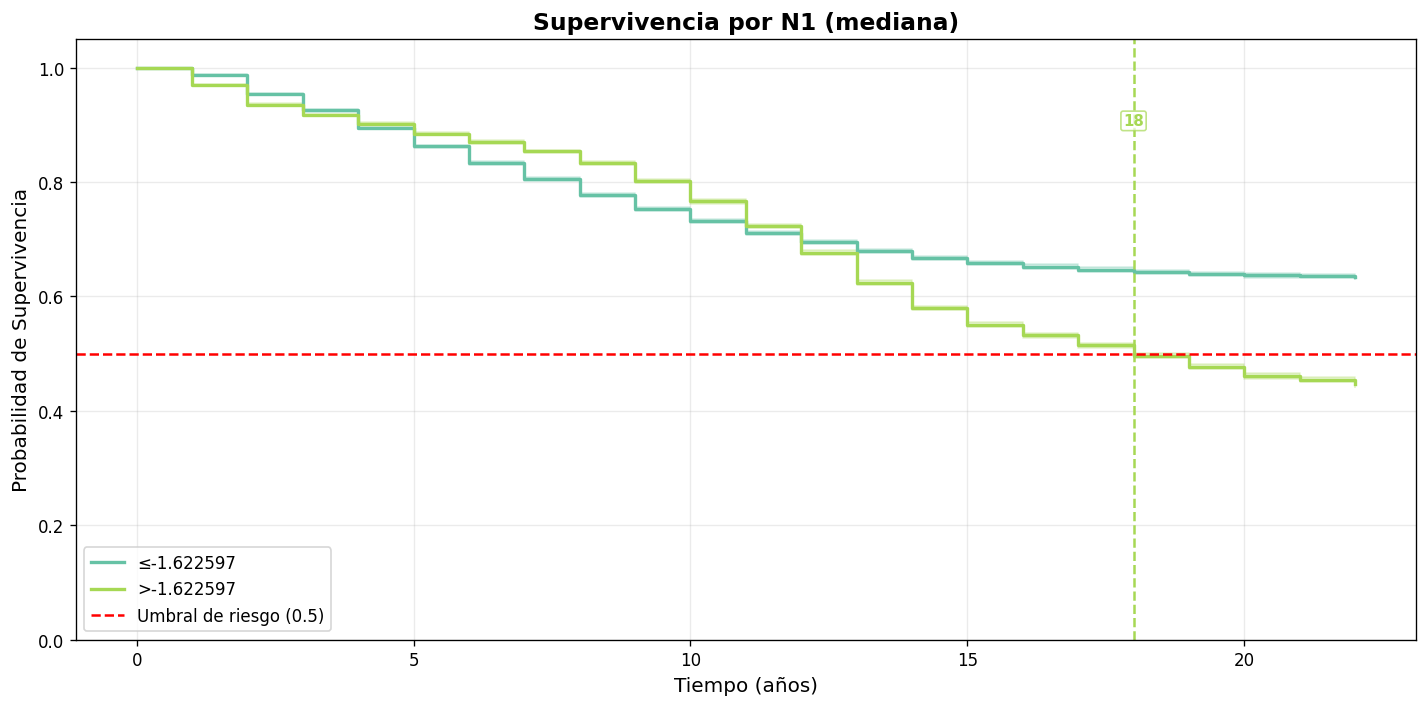

In [104]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por N1 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.2 N2

In [105]:
groups = pd.cut(all_data['N2'], bins=[-np.inf, -1.0487861991036933, np.inf], labels=['≤-1.048786', '>-1.048786'], include_lowest=True)
present = [l for l in ['≤-1.048786', '>-1.048786'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: N2')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: N2
  ≤-1.048786                n=59,082  eventos=24,052  mediana=No alcanzada
  >-1.048786                n=57,970  eventos=23,700  mediana=No alcanzada

Log-rank p = 1.49e-11


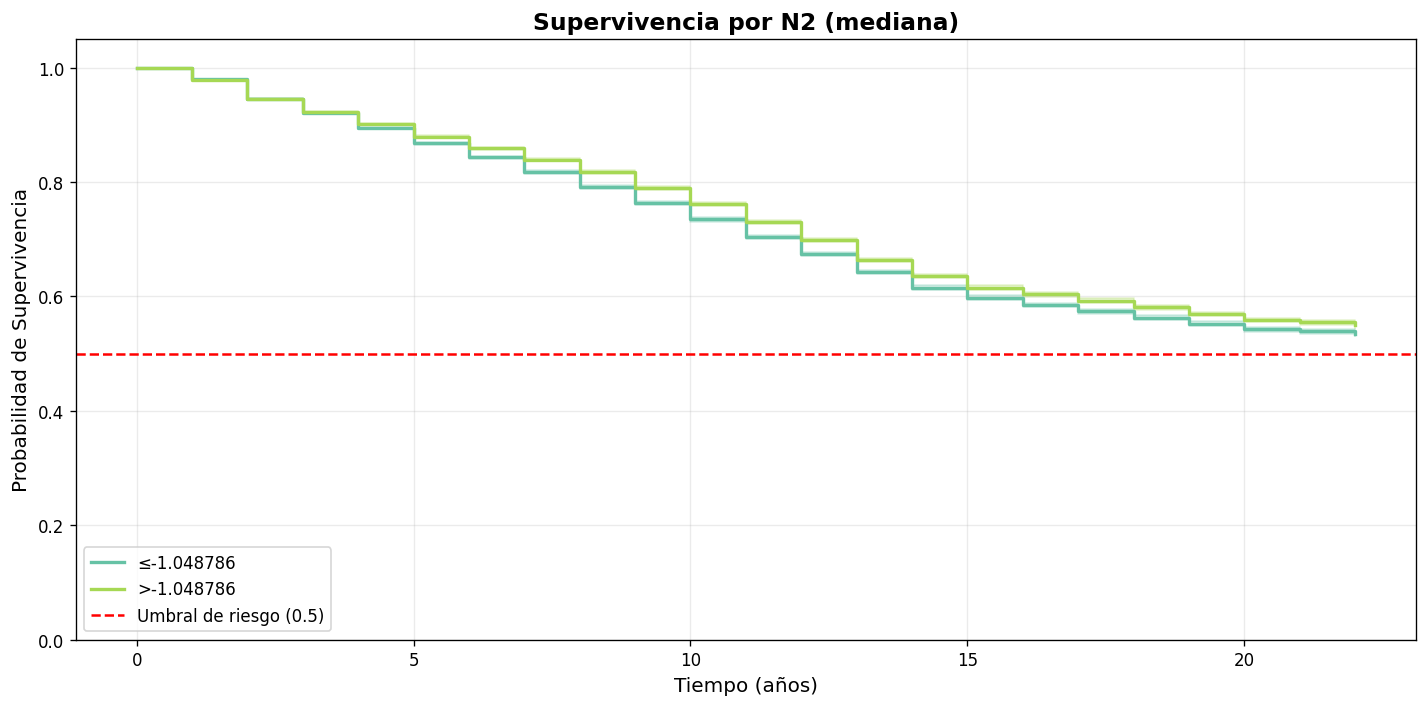

In [106]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por N2 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.3 N6

In [107]:
groups = pd.cut(all_data['N6'], bins=[-np.inf, -0.2237686501078571, np.inf], labels=['≤-0.223769', '>-0.223769'], include_lowest=True)
present = [l for l in ['≤-0.223769', '>-0.223769'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: N6')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: N6
  ≤-0.223769                n=114,782  eventos=46,074  mediana=No alcanzada
  >-0.223769                n= 2,270  eventos=1,678  mediana=5.0

Log-rank p = 0.00e+00


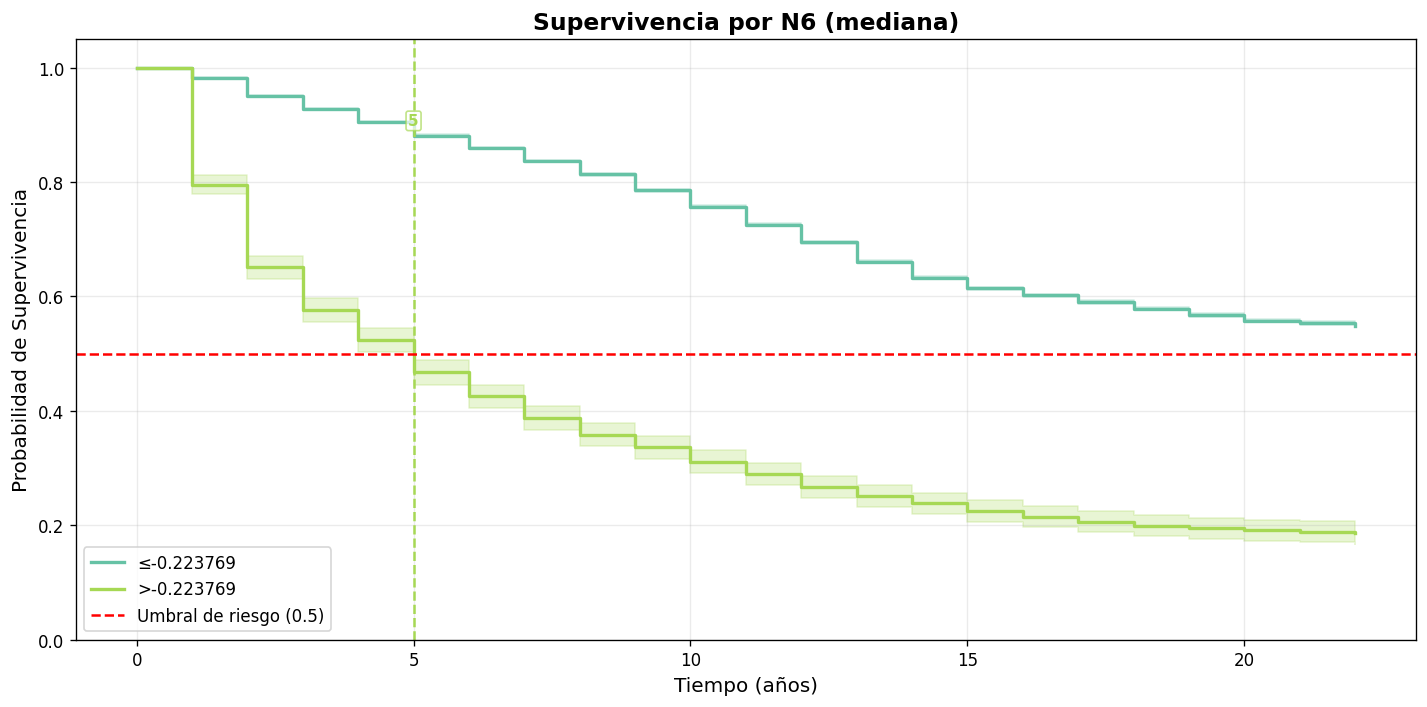

In [108]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por N6 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.4 N7

In [109]:
groups = pd.cut(all_data['N7'], bins=[-np.inf, -0.2761975708403391, np.inf], labels=['≤-0.276198', '>-0.276198'], include_lowest=True)
present = [l for l in ['≤-0.276198', '>-0.276198'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: N7')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: N7
  ≤-0.276198                n=110,757  eventos=44,869  mediana=No alcanzada
  >-0.276198                n= 6,295  eventos=2,883  mediana=No alcanzada

Log-rank p = 3.39e-21


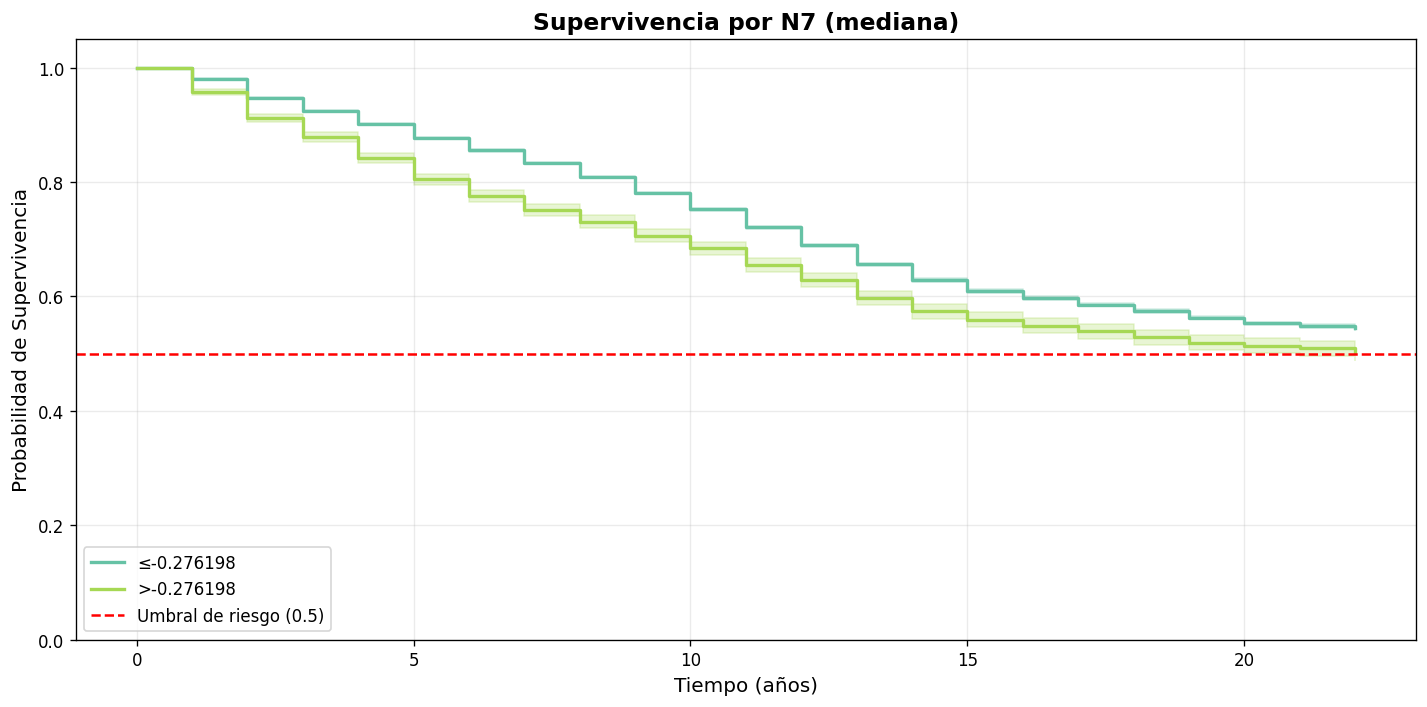

In [110]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por N7 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.5 N12

In [111]:
groups = pd.cut(all_data['N12'], bins=[-np.inf, -0.4766110273700397, np.inf], labels=['≤-0.476611', '>-0.476611'], include_lowest=True)
present = [l for l in ['≤-0.476611', '>-0.476611'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: N12')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: N12
  ≤-0.476611                n=70,304  eventos=28,036  mediana=No alcanzada
  >-0.476611                n=46,748  eventos=19,716  mediana=No alcanzada

Log-rank p = 4.13e-01


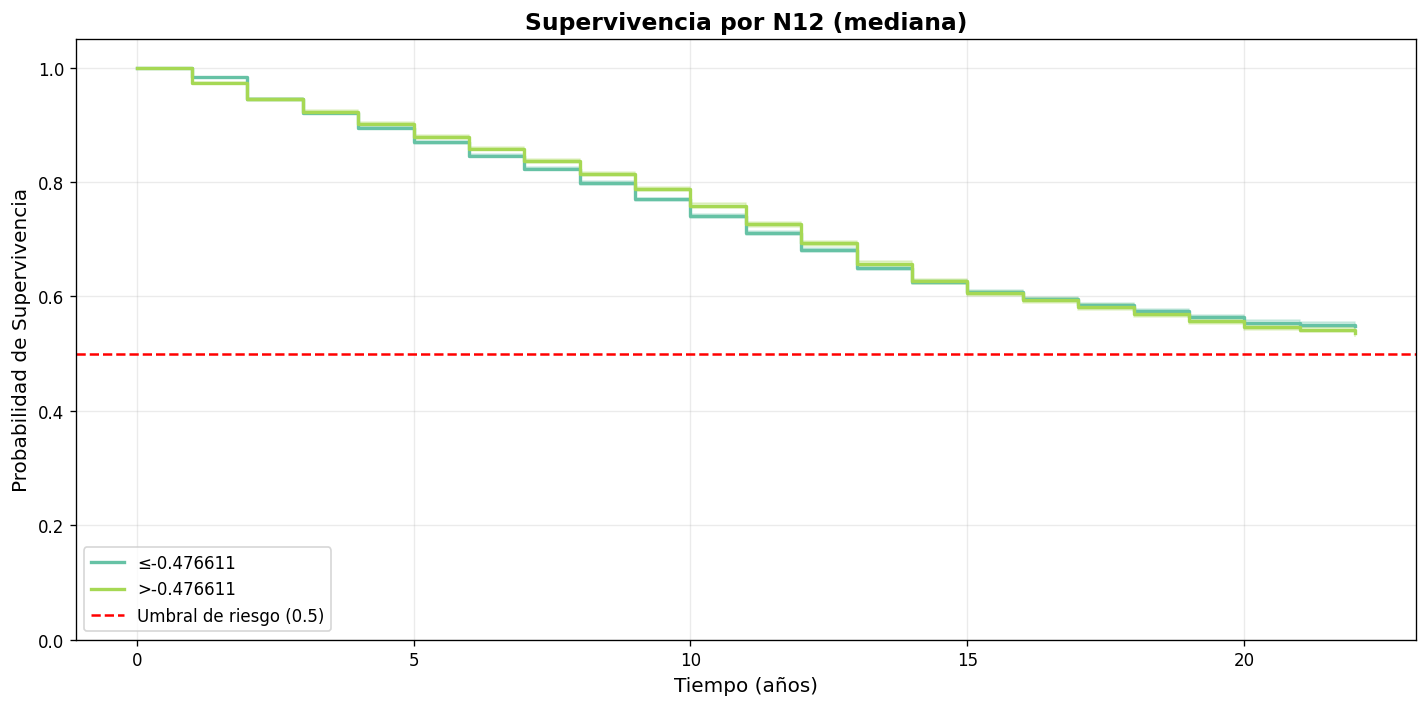

In [112]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por N12 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.6 N13

In [113]:
groups = pd.cut(all_data['N13'], bins=[-np.inf, -0.8842833759313509, np.inf], labels=['≤-0.884283', '>-0.884283'], include_lowest=True)
present = [l for l in ['≤-0.884283', '>-0.884283'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: N13')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: N13
  ≤-0.884283                n=77,361  eventos=31,997  mediana=No alcanzada
  >-0.884283                n=39,691  eventos=15,755  mediana=No alcanzada

Log-rank p = 9.33e-23


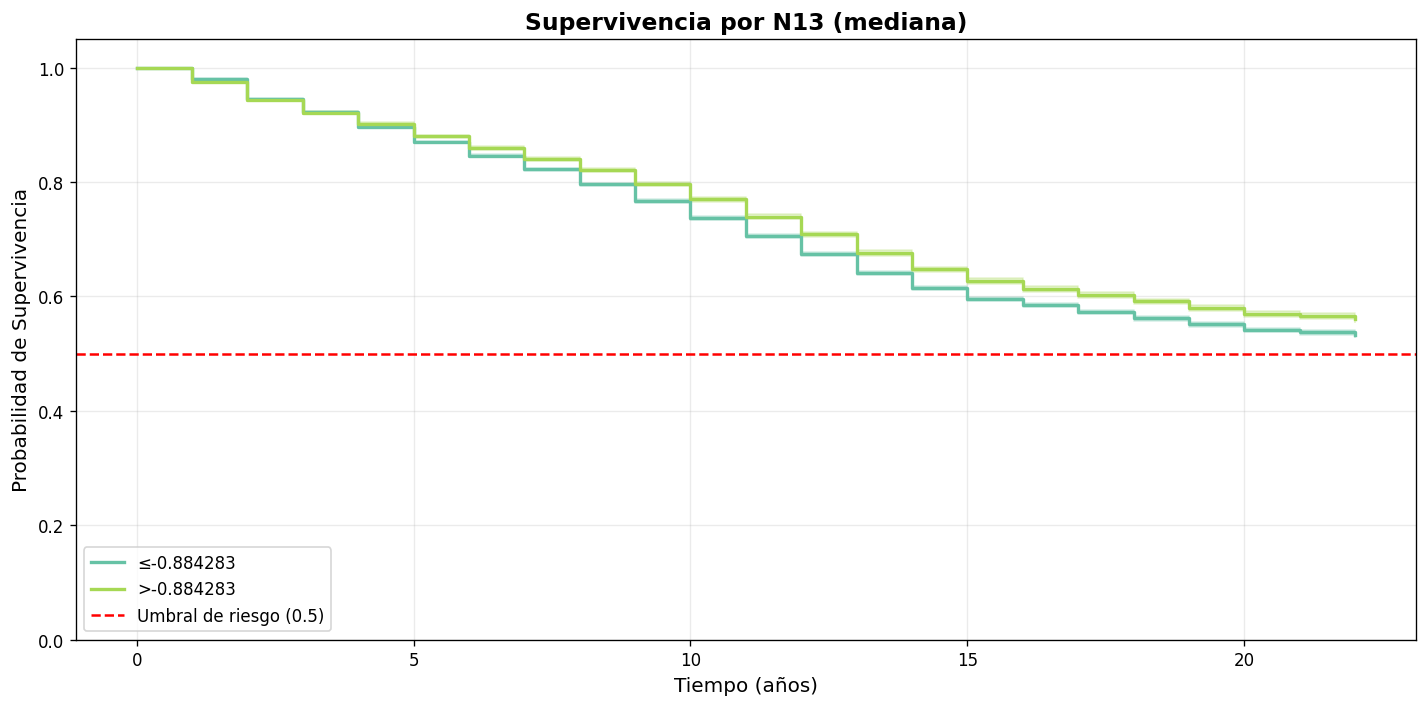

In [114]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por N13 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.7 N14

In [115]:
groups = pd.cut(all_data['N14'], bins=[-np.inf, -1.1787732610576815, np.inf], labels=['≤-1.178773', '>-1.178773'], include_lowest=True)
present = [l for l in ['≤-1.178773', '>-1.178773'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: N14')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: N14
  ≤-1.178773                n=91,940  eventos=31,221  mediana=No alcanzada
  >-1.178773                n=25,112  eventos=16,531  mediana=6.0

Log-rank p = 0.00e+00


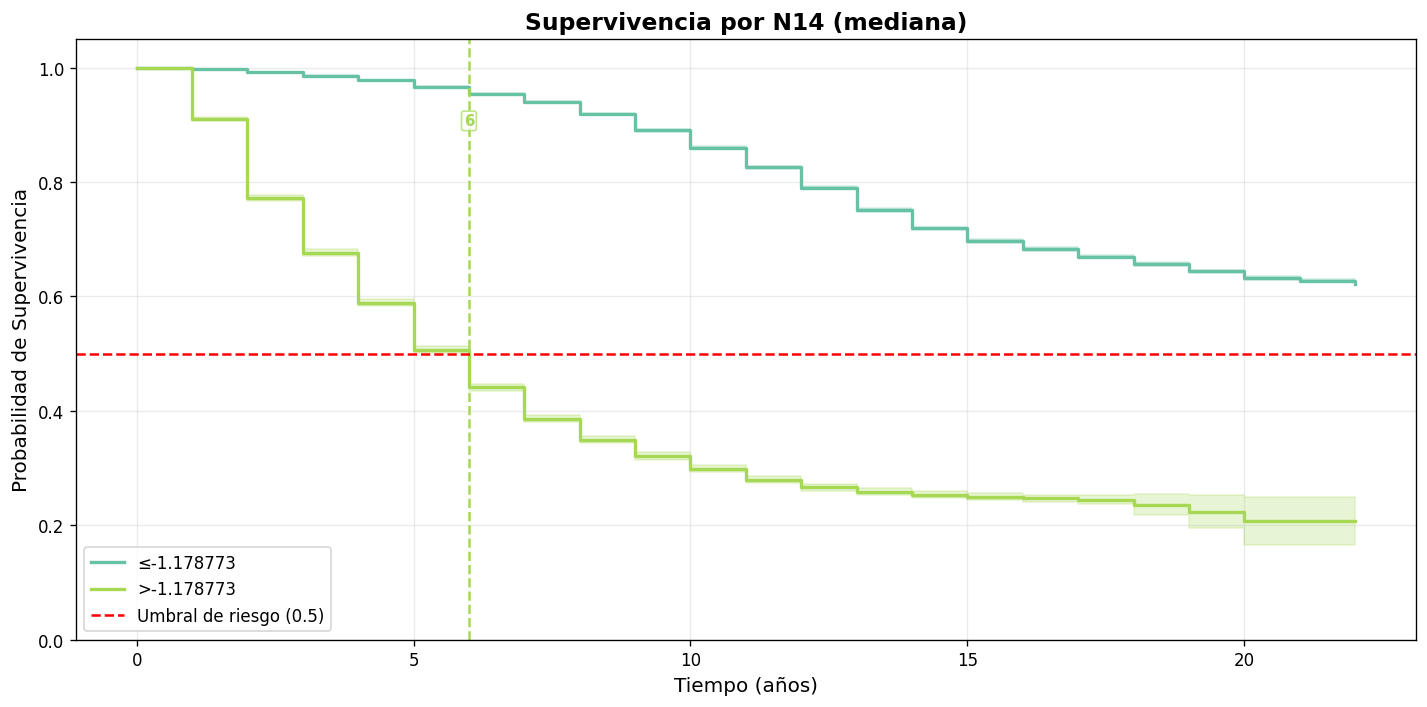

In [116]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por N14 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.8 F16

In [117]:
groups = pd.cut(all_data['F16'], bins=[-np.inf, -0.0275617826934966, np.inf], labels=['≤-0.027562', '>-0.027562'], include_lowest=True)
present = [l for l in ['≤-0.027562', '>-0.027562'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F16')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F16
  ≤-0.027562                n=64,817  eventos=22,647  mediana=No alcanzada
  >-0.027562                n=52,235  eventos=25,105  mediana=16.0

Log-rank p = 0.00e+00


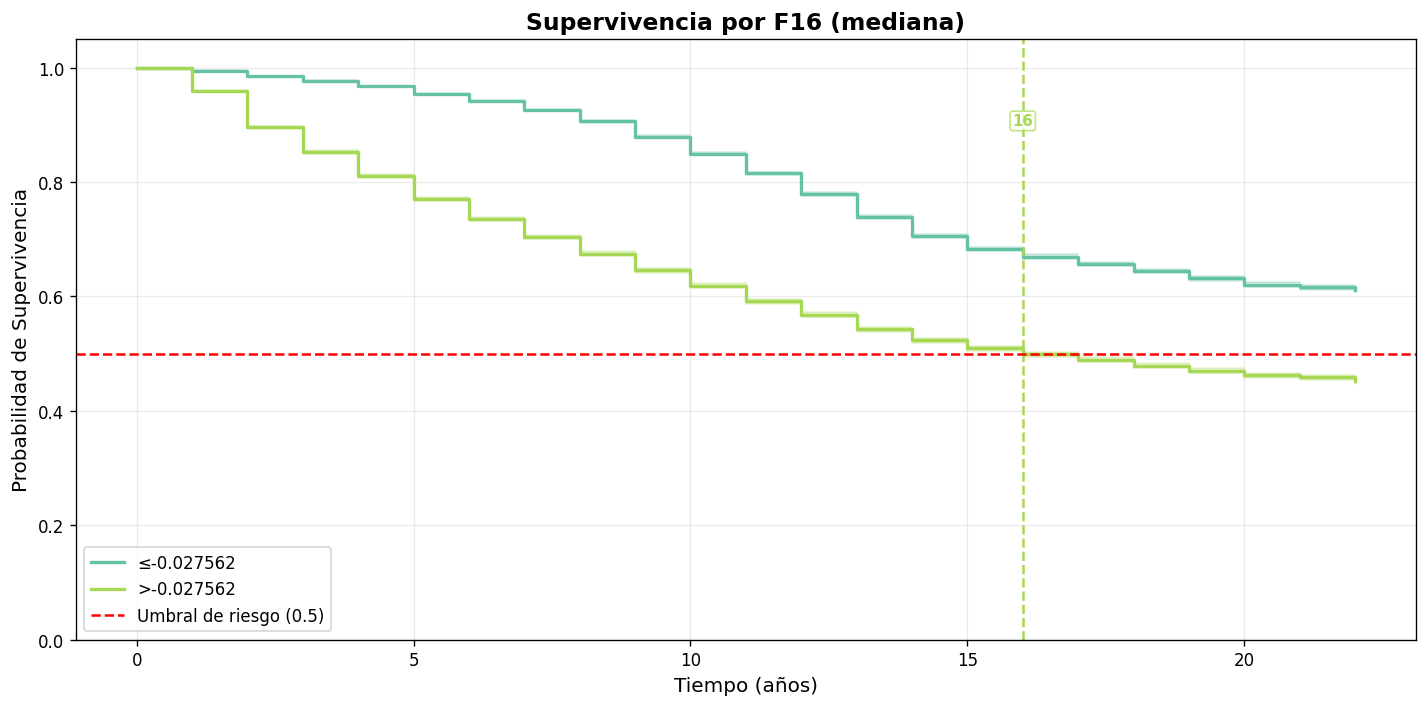

In [118]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F16 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.9 F17

In [119]:
groups = pd.cut(all_data['F17'], bins=[-np.inf, -0.1102836570324829, np.inf], labels=['≤-0.110284', '>-0.110284'], include_lowest=True)
present = [l for l in ['≤-0.110284', '>-0.110284'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F17')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F17
  ≤-0.110284                n=58,526  eventos=23,167  mediana=No alcanzada
  >-0.110284                n=58,526  eventos=24,585  mediana=No alcanzada

Log-rank p = 2.05e-07


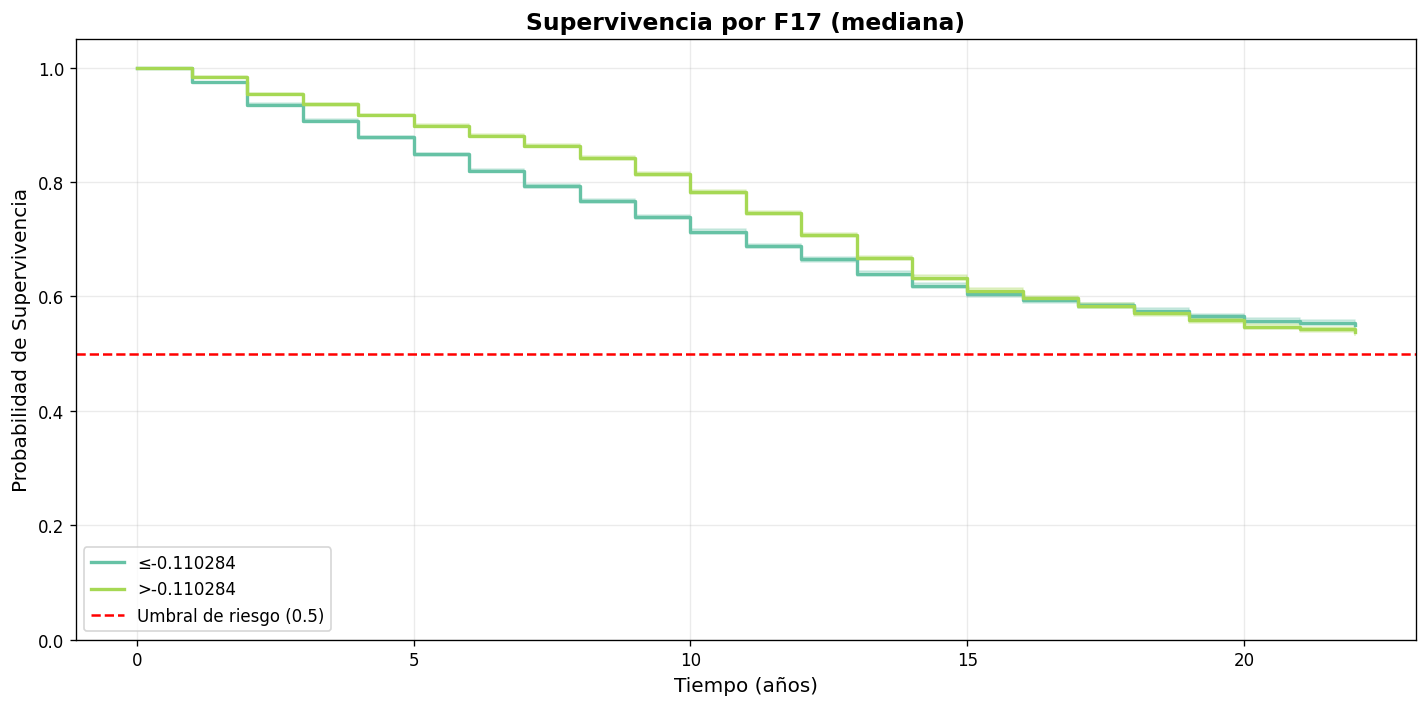

In [120]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F17 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.10 F18

In [121]:
groups = pd.cut(all_data['F18'], bins=[-np.inf, 0.12424554007456075, np.inf], labels=['≤0.124246', '>0.124246'], include_lowest=True)
present = [l for l in ['≤0.124246', '>0.124246'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F18')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F18
  ≤0.124246                 n=58,526  eventos=25,496  mediana=No alcanzada
  >0.124246                 n=58,526  eventos=22,256  mediana=No alcanzada

Log-rank p = 0.00e+00


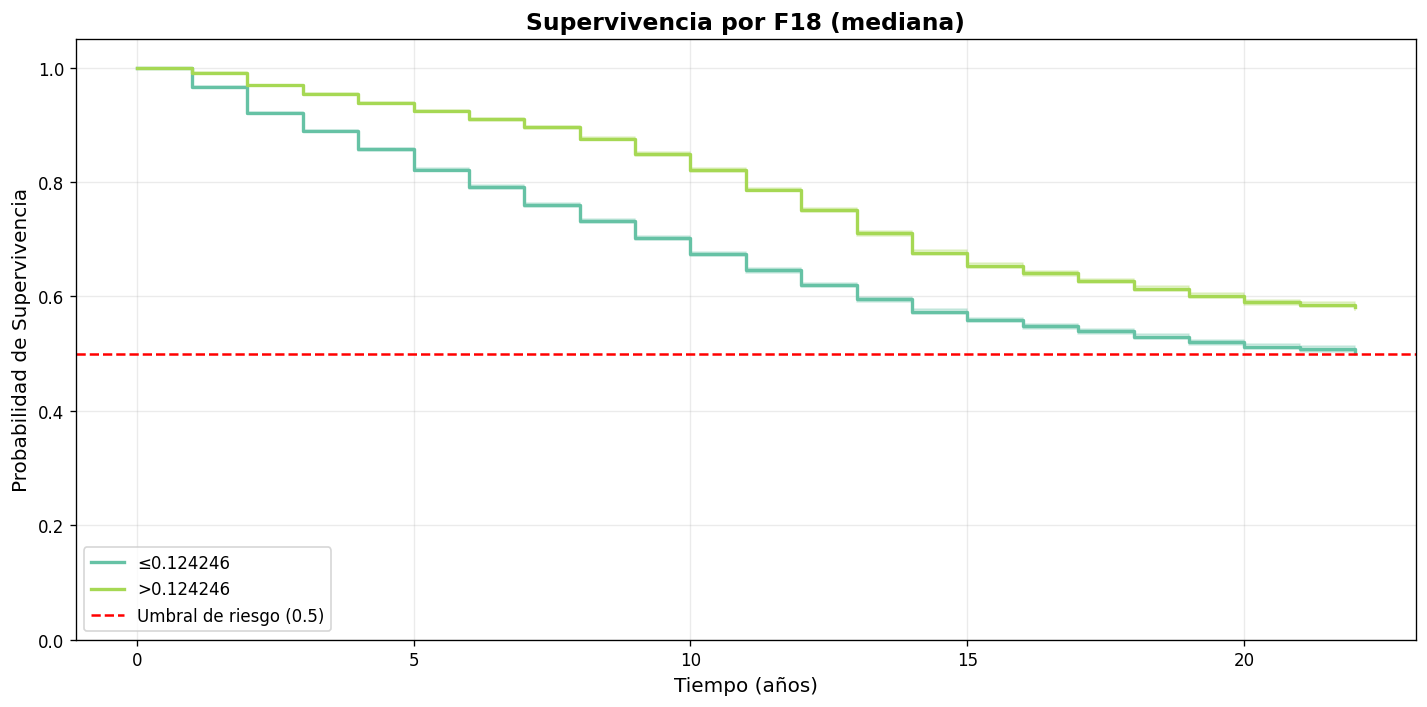

In [122]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F18 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.11 F19

In [123]:
groups = pd.cut(all_data['F19'], bins=[-np.inf, -0.019227499132141848, np.inf], labels=['≤-0.019227', '>-0.019227'], include_lowest=True)
present = [l for l in ['≤-0.019227', '>-0.019227'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F19')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F19
  ≤-0.019227                n=58,526  eventos=24,053  mediana=No alcanzada
  >-0.019227                n=58,526  eventos=23,699  mediana=No alcanzada

Log-rank p = 3.53e-16


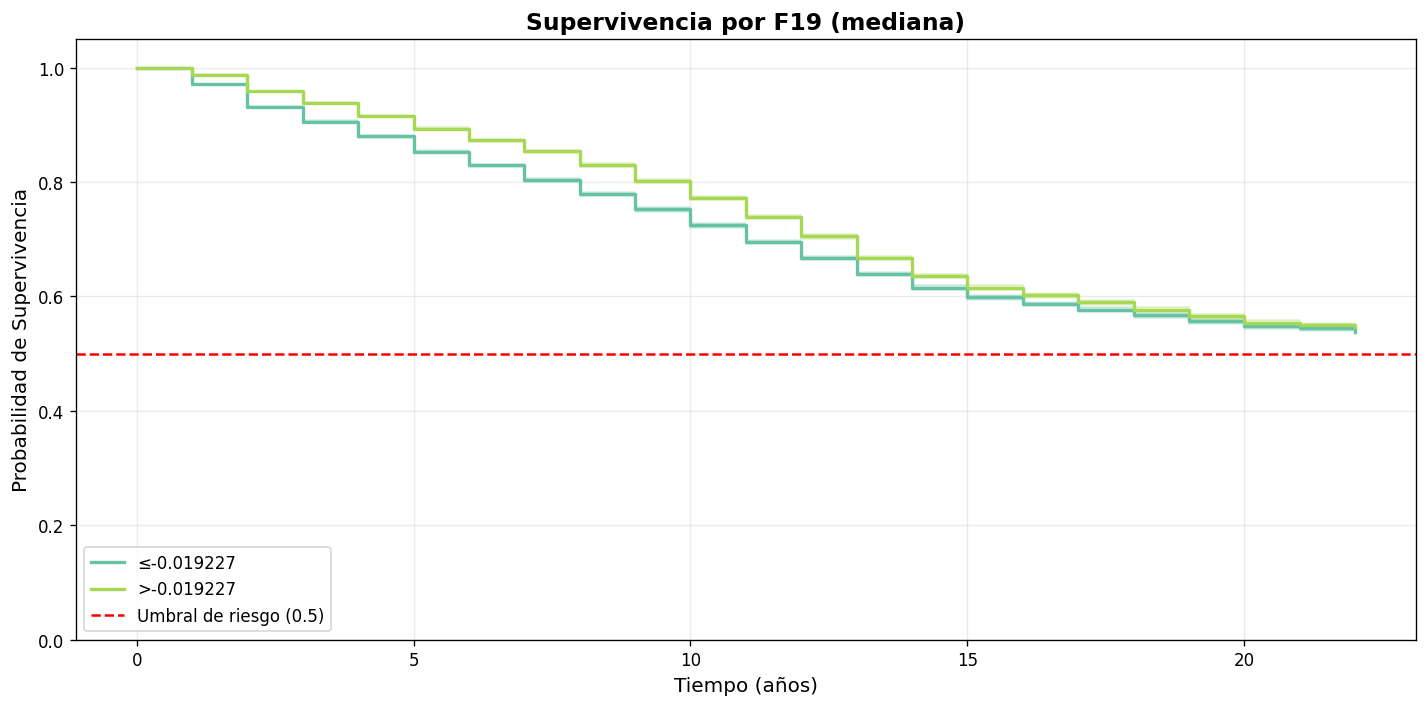

In [124]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F19 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.12 F20

In [125]:
groups = pd.cut(all_data['F20'], bins=[-np.inf, 0.00116042988434835, np.inf], labels=['≤0.001160', '>0.001160'], include_lowest=True)
present = [l for l in ['≤0.001160', '>0.001160'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F20')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F20
  ≤0.001160                 n=58,526  eventos=27,710  mediana=17.0
  >0.001160                 n=58,526  eventos=20,042  mediana=No alcanzada

Log-rank p = 0.00e+00


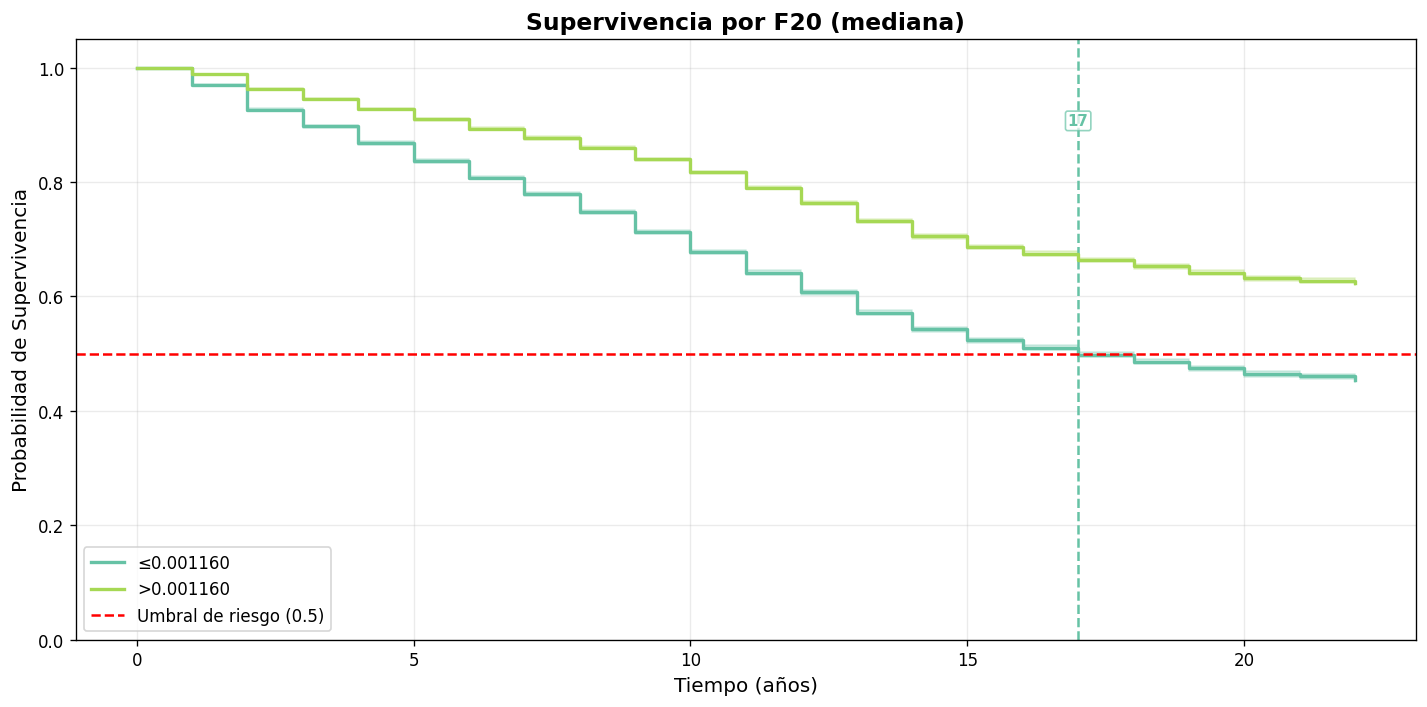

In [126]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F20 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.13 F21

In [127]:
groups = pd.cut(all_data['F21'], bins=[-np.inf, 0.0008373162195483, np.inf], labels=['≤0.000837', '>0.000837'], include_lowest=True)
present = [l for l in ['≤0.000837', '>0.000837'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F21')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F21
  ≤0.000837                 n=58,526  eventos=27,582  mediana=17.0
  >0.000837                 n=58,526  eventos=20,170  mediana=No alcanzada

Log-rank p = 0.00e+00


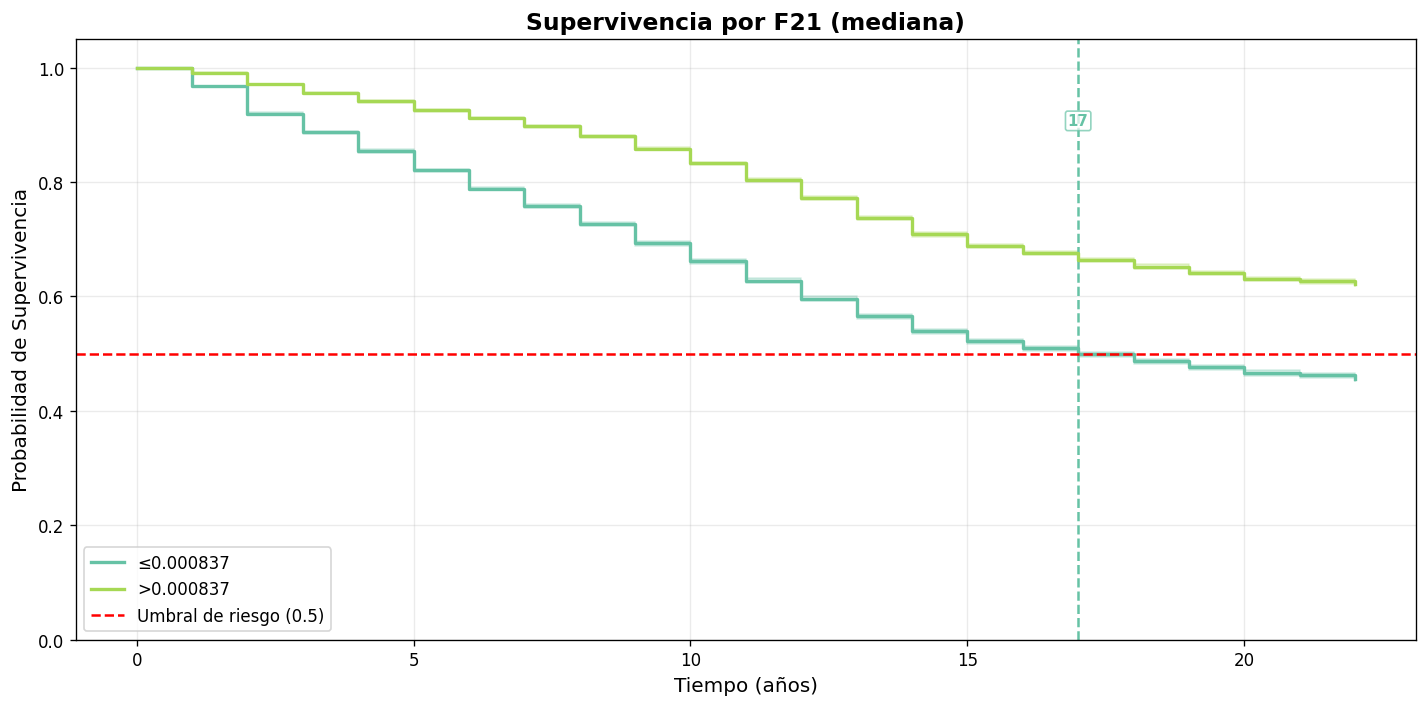

In [128]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F21 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.14 F22

In [129]:
groups = pd.cut(all_data['F22'], bins=[-np.inf, -7.160070960486965e-05, np.inf], labels=['≤-0.000072', '>-0.000072'], include_lowest=True)
present = [l for l in ['≤-0.000072', '>-0.000072'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F22')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F22
  ≤-0.000072                n=58,526  eventos=24,871  mediana=No alcanzada
  >-0.000072                n=58,526  eventos=22,881  mediana=No alcanzada

Log-rank p = 1.46e-60


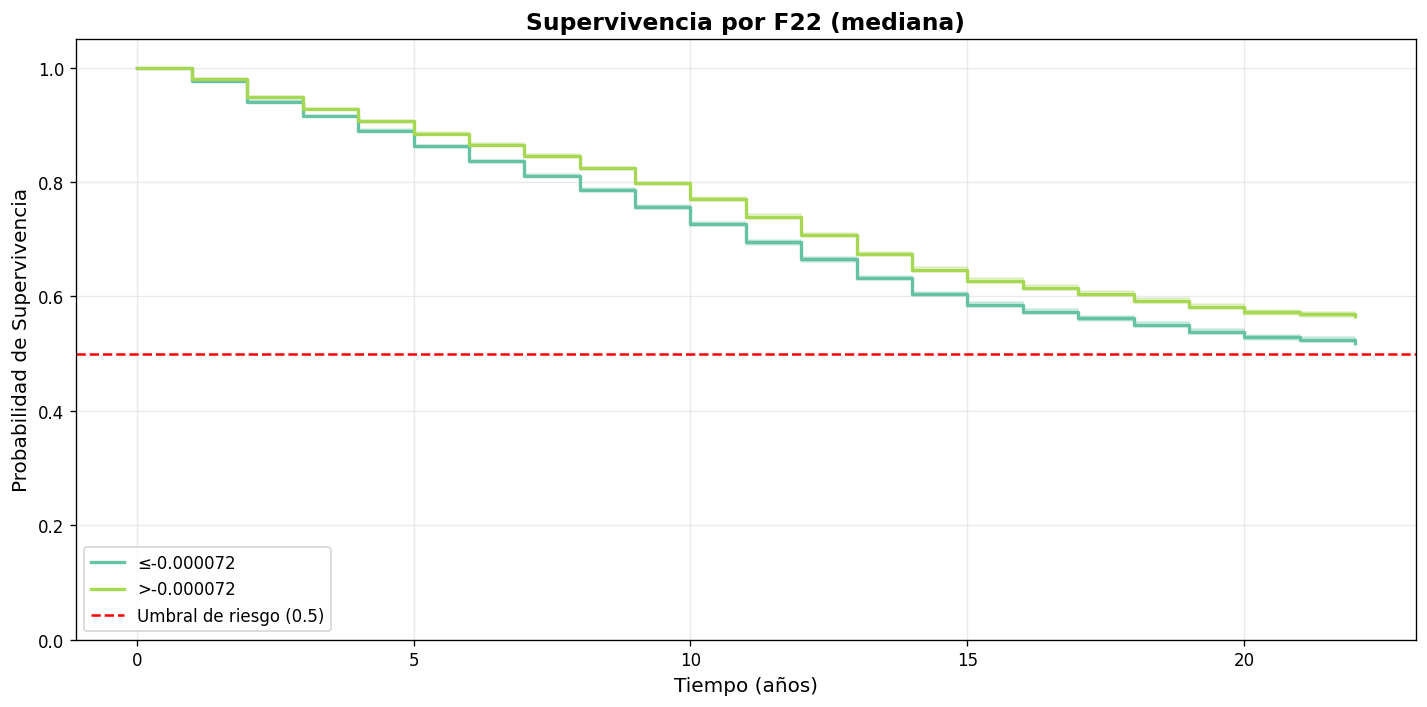

In [130]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F22 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.15 F23

In [131]:
groups = pd.cut(all_data['F23'], bins=[-np.inf, 0.0002419466005621, np.inf], labels=['≤0.000242', '>0.000242'], include_lowest=True)
present = [l for l in ['≤0.000242', '>0.000242'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F23')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F23
  ≤0.000242                 n=58,526  eventos=26,203  mediana=20.0
  >0.000242                 n=58,526  eventos=21,549  mediana=No alcanzada

Log-rank p = 0.00e+00


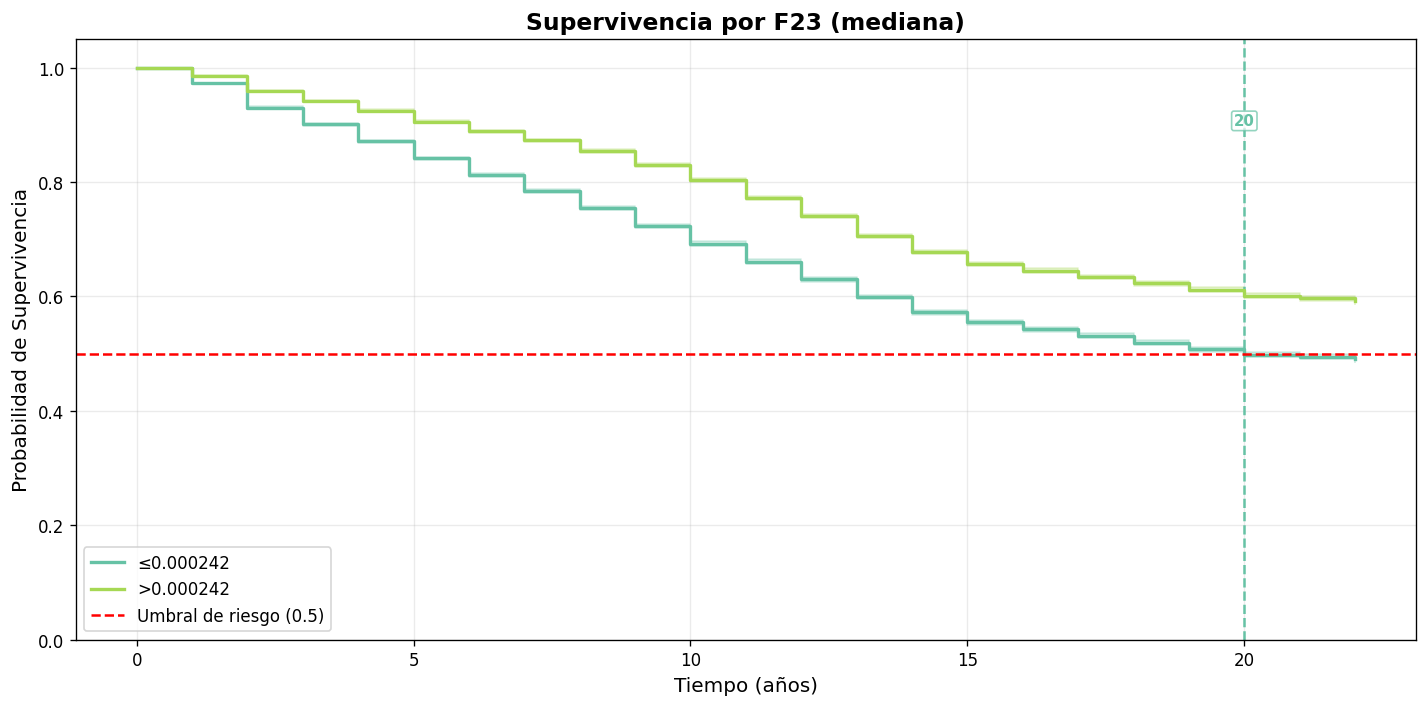

In [132]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F23 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.16 F24

In [133]:
groups = pd.cut(all_data['F24'], bins=[-np.inf, -0.00589314084045845, np.inf], labels=['≤-0.005893', '>-0.005893'], include_lowest=True)
present = [l for l in ['≤-0.005893', '>-0.005893'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F24')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F24
  ≤-0.005893                n=58,526  eventos=24,942  mediana=No alcanzada
  >-0.005893                n=58,526  eventos=22,810  mediana=No alcanzada

Log-rank p = 5.35e-195


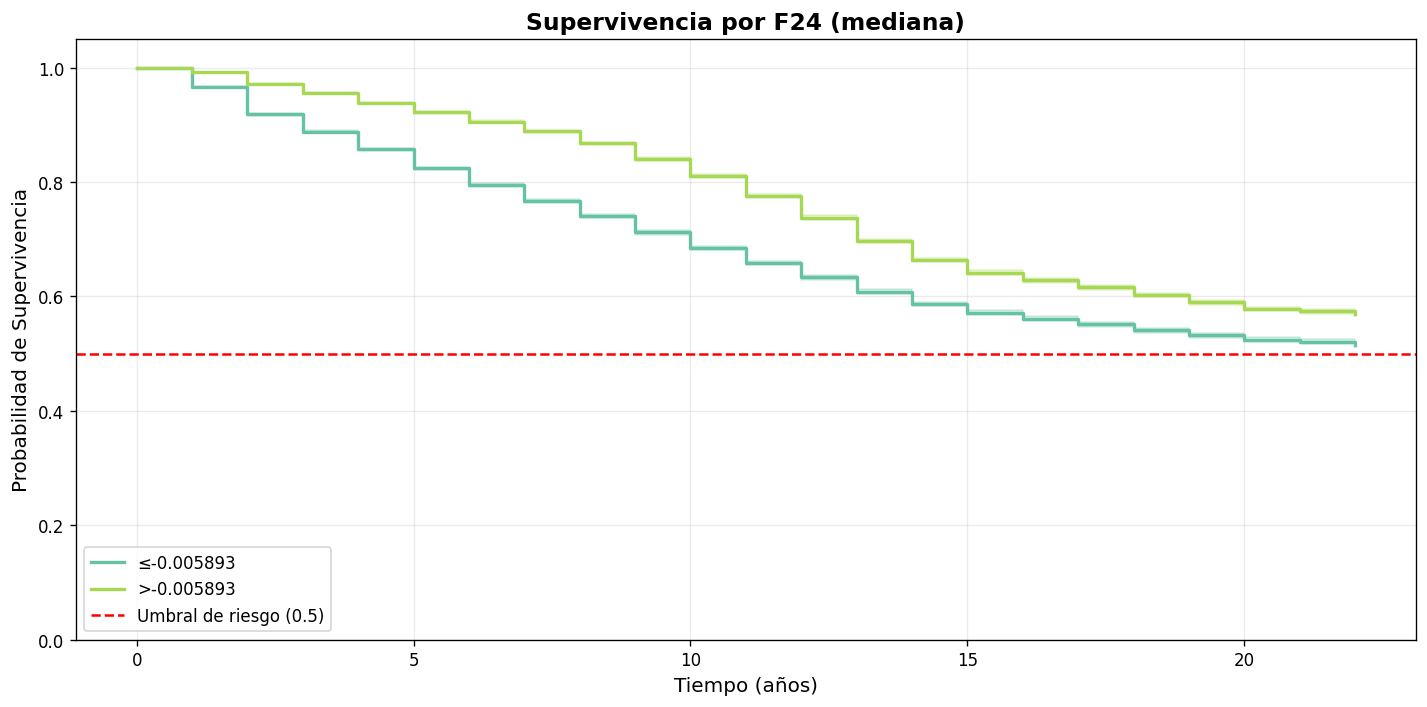

In [134]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F24 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.17 F25

In [135]:
groups = pd.cut(all_data['F25'], bins=[-np.inf, -0.0036464951493346, np.inf], labels=['≤-0.003646', '>-0.003646'], include_lowest=True)
present = [l for l in ['≤-0.003646', '>-0.003646'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F25')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F25
  ≤-0.003646                n=58,526  eventos=26,791  mediana=20.0
  >-0.003646                n=58,526  eventos=20,961  mediana=No alcanzada

Log-rank p = 3.15e-261


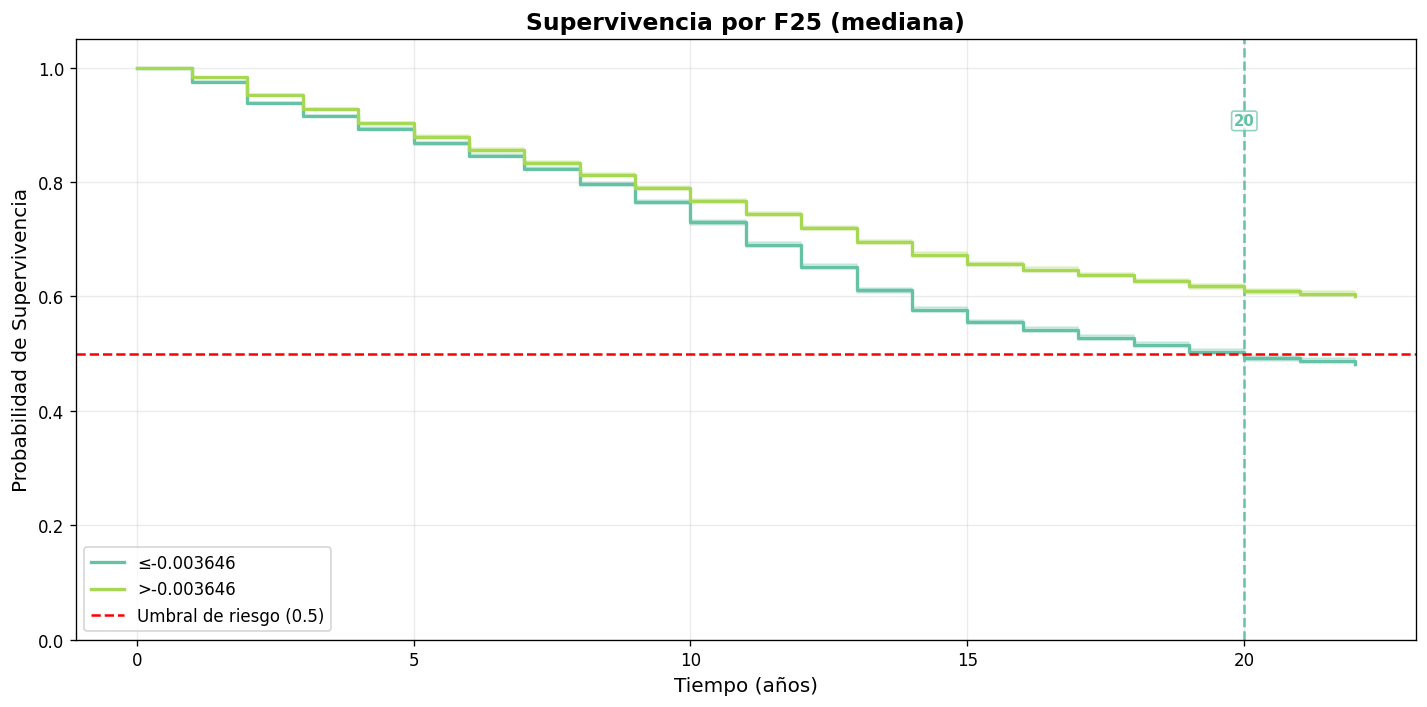

In [136]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F25 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.18 F27

In [137]:
groups = pd.cut(all_data['F27'], bins=[-np.inf, -0.00016456594966670002, np.inf], labels=['≤-0.000165', '>-0.000165'], include_lowest=True)
present = [l for l in ['≤-0.000165', '>-0.000165'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F27')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F27
  ≤-0.000165                n=58,526  eventos=20,571  mediana=No alcanzada
  >-0.000165                n=58,526  eventos=27,181  mediana=18.0

Log-rank p = 0.00e+00


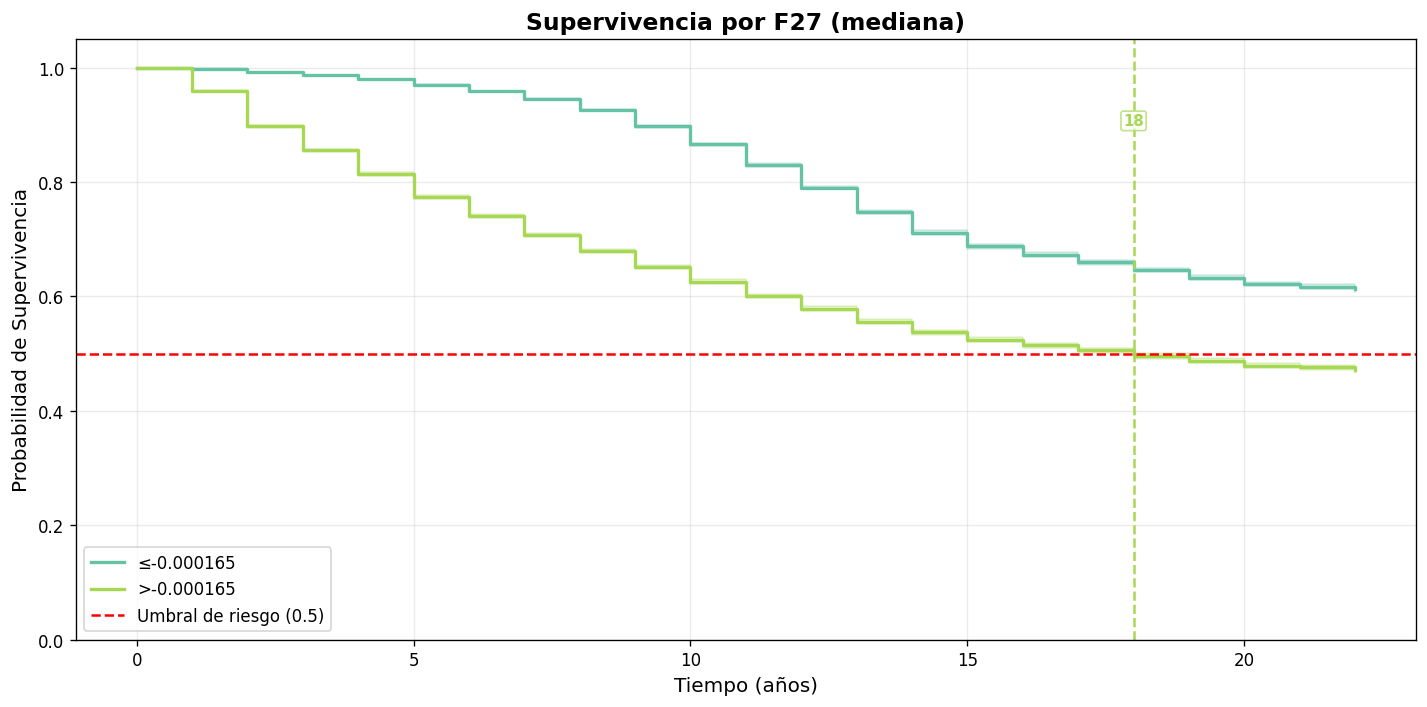

In [138]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F27 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.19 F28

In [139]:
groups = pd.cut(all_data['F28'], bins=[-np.inf, -0.3017176399612945, np.inf], labels=['≤-0.301718', '>-0.301718'], include_lowest=True)
present = [l for l in ['≤-0.301718', '>-0.301718'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F28')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F28
  ≤-0.301718                n=58,526  eventos=23,468  mediana=No alcanzada
  >-0.301718                n=58,526  eventos=24,284  mediana=No alcanzada

Log-rank p = 4.43e-23


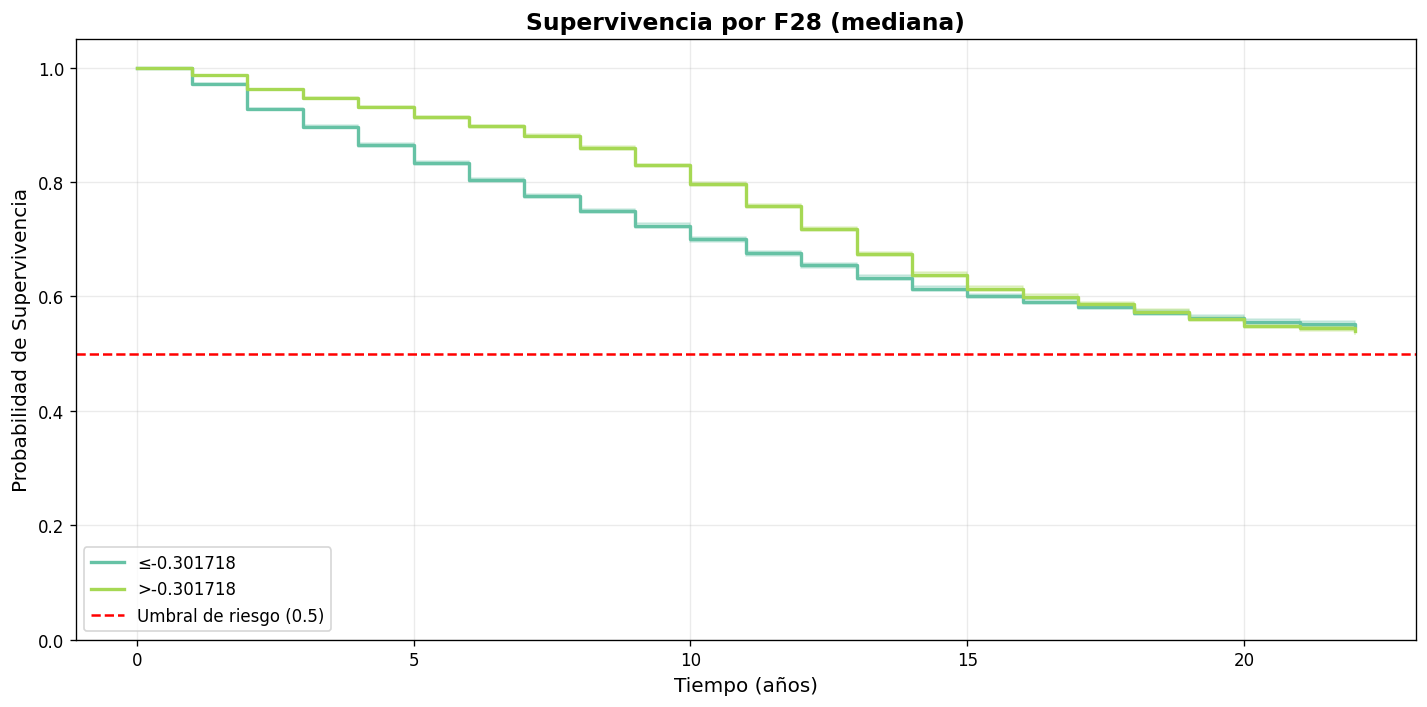

In [140]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F28 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.20 F29

In [141]:
groups = pd.cut(all_data['F29'], bins=[-np.inf, -0.00309284135639405, np.inf], labels=['≤-0.003093', '>-0.003093'], include_lowest=True)
present = [l for l in ['≤-0.003093', '>-0.003093'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F29')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F29
  ≤-0.003093                n=58,526  eventos=21,241  mediana=No alcanzada
  >-0.003093                n=58,526  eventos=26,511  mediana=20.0

Log-rank p = 5.04e-306


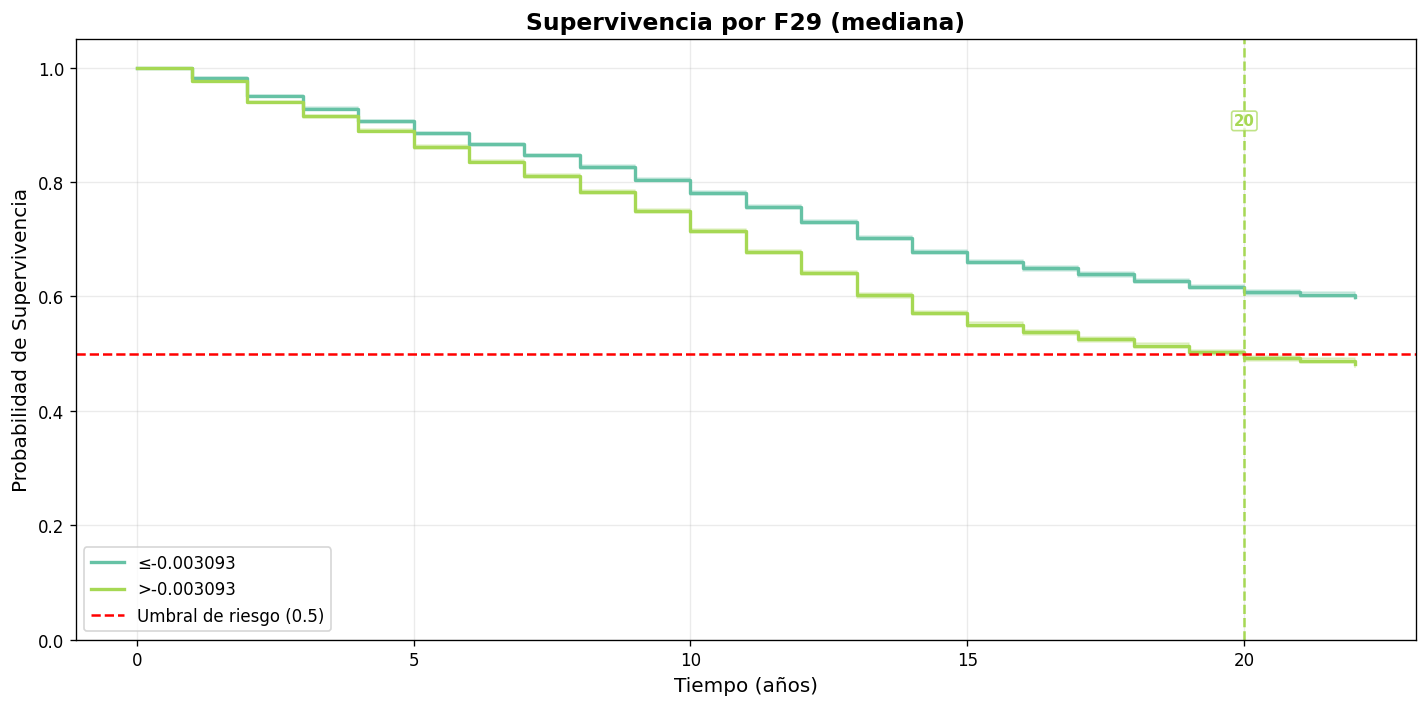

In [142]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F29 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.21 F30

In [143]:
groups = pd.cut(all_data['F30'], bins=[-np.inf, 0.00070095947981095, np.inf], labels=['≤0.000701', '>0.000701'], include_lowest=True)
present = [l for l in ['≤0.000701', '>0.000701'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F30')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F30
  ≤0.000701                 n=58,526  eventos=21,834  mediana=No alcanzada
  >0.000701                 n=58,526  eventos=25,918  mediana=20.0

Log-rank p = 0.00e+00


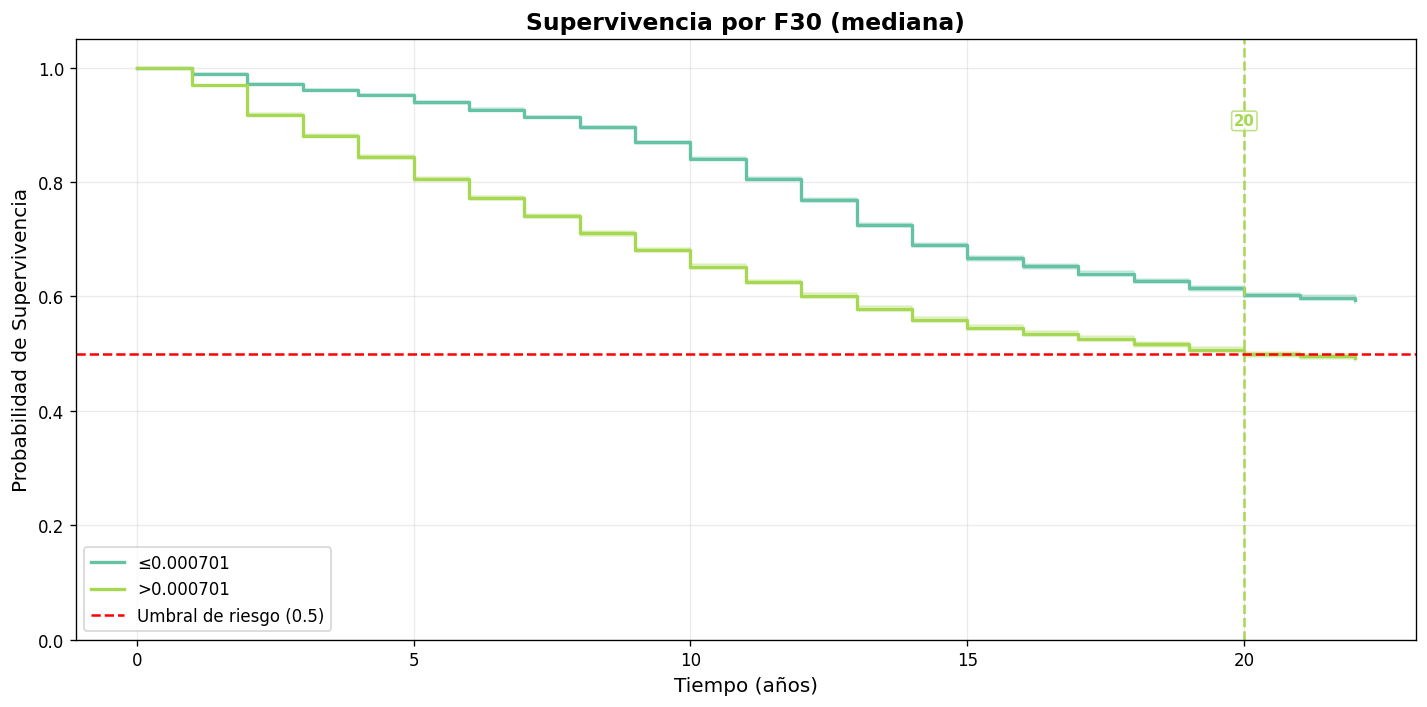

In [144]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F30 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.22 F31

In [145]:
groups = pd.cut(all_data['F31'], bins=[-np.inf, -0.00698457946564455, np.inf], labels=['≤-0.006985', '>-0.006985'], include_lowest=True)
present = [l for l in ['≤-0.006985', '>-0.006985'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F31')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F31
  ≤-0.006985                n=58,526  eventos=23,204  mediana=No alcanzada
  >-0.006985                n=58,526  eventos=24,548  mediana=No alcanzada

Log-rank p = 1.52e-04


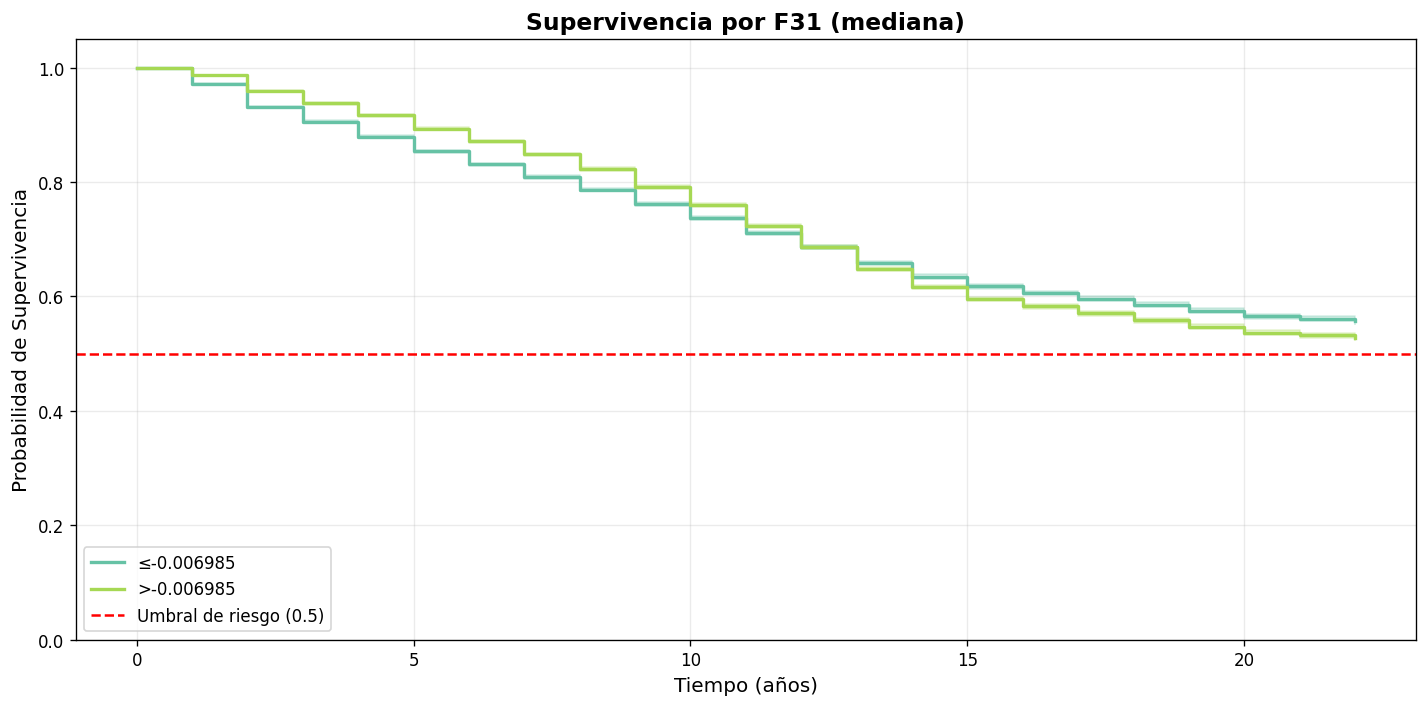

In [146]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F31 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.23 F33

In [147]:
groups = pd.cut(all_data['F33'], bins=[-np.inf, 0.0006265485729563, np.inf], labels=['≤0.000627', '>0.000627'], include_lowest=True)
present = [l for l in ['≤0.000627', '>0.000627'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F33')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F33
  ≤0.000627                 n=58,526  eventos=24,571  mediana=No alcanzada
  >0.000627                 n=58,526  eventos=23,181  mediana=No alcanzada

Log-rank p = 2.68e-10


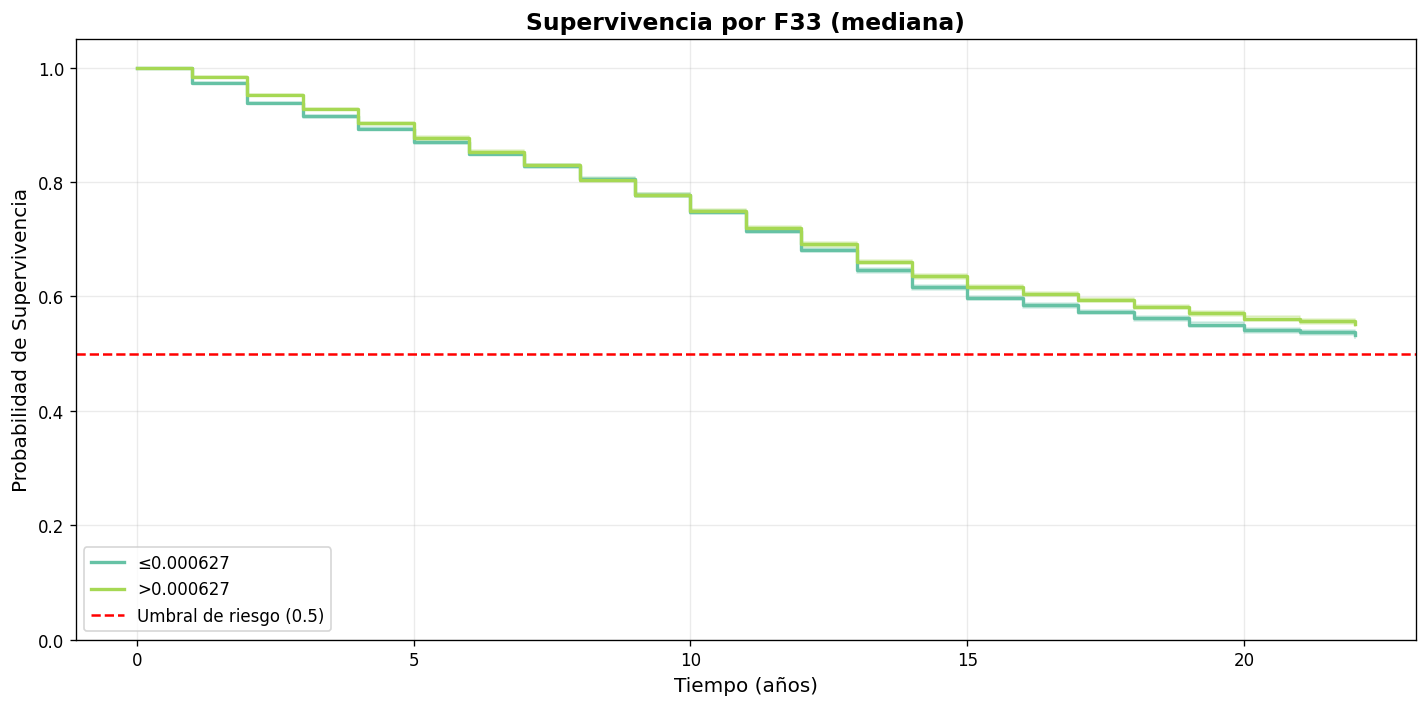

In [148]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F33 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.24 F34

In [149]:
groups = pd.cut(all_data['F34'], bins=[-np.inf, 0.11833800266014241, np.inf], labels=['≤0.118338', '>0.118338'], include_lowest=True)
present = [l for l in ['≤0.118338', '>0.118338'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F34')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F34
  ≤0.118338                 n=58,526  eventos=22,951  mediana=No alcanzada
  >0.118338                 n=58,526  eventos=24,801  mediana=No alcanzada

Log-rank p = 1.12e-51


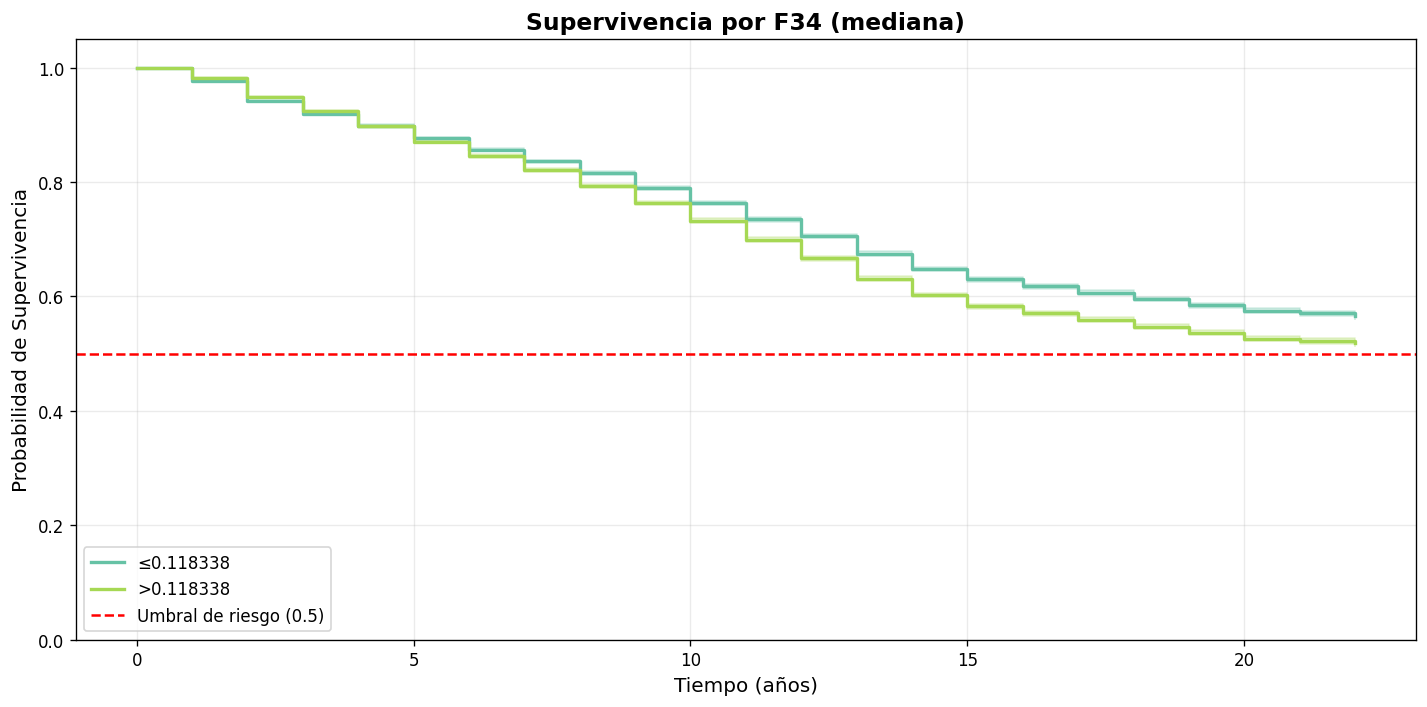

In [150]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F34 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.25 F35

In [151]:
groups = pd.cut(all_data['F35'], bins=[-np.inf, -0.0006276716095441, np.inf], labels=['≤-0.000628', '>-0.000628'], include_lowest=True)
present = [l for l in ['≤-0.000628', '>-0.000628'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F35')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F35
  ≤-0.000628                n=58,526  eventos=25,365  mediana=No alcanzada
  >-0.000628                n=58,526  eventos=22,387  mediana=No alcanzada

Log-rank p = 8.75e-79


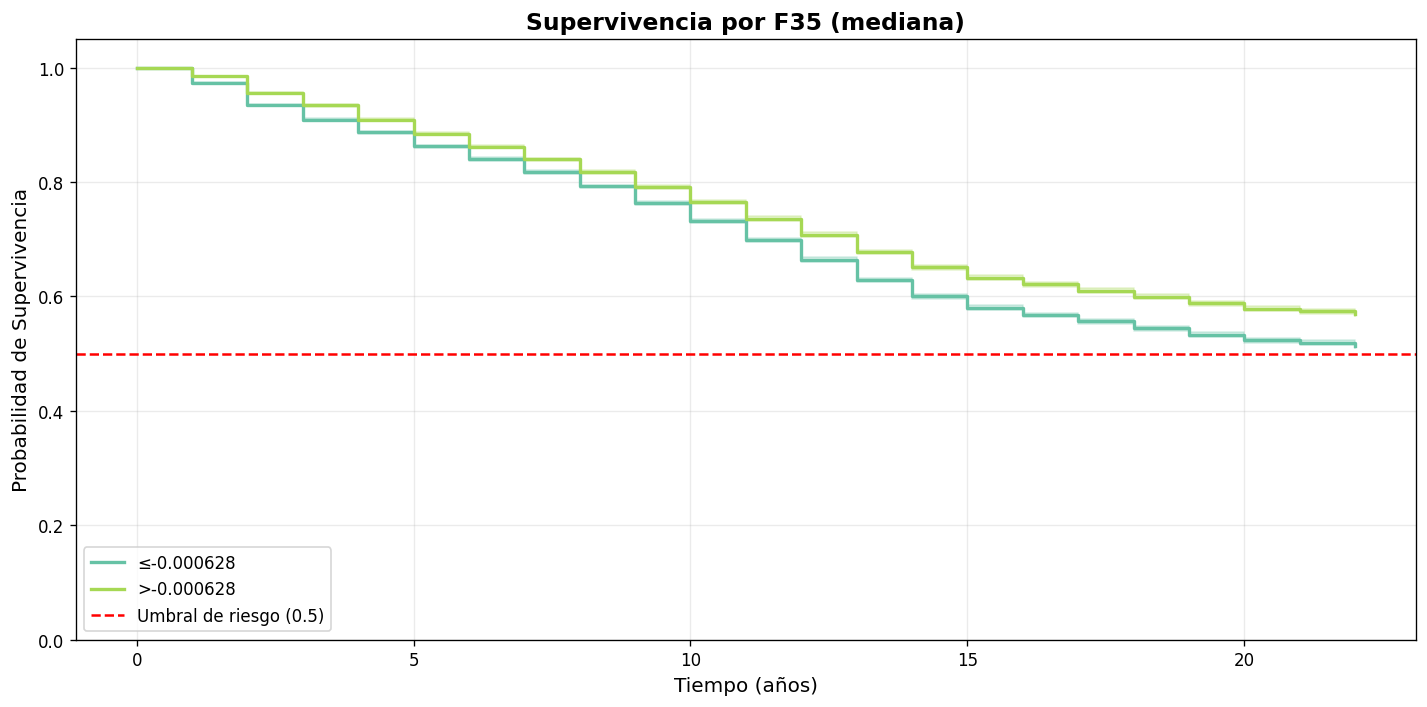

In [152]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F35 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.26 F36

In [153]:
groups = pd.cut(all_data['F36'], bins=[-np.inf, -0.0020223558901242503, np.inf], labels=['≤-0.002022', '>-0.002022'], include_lowest=True)
present = [l for l in ['≤-0.002022', '>-0.002022'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F36')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F36
  ≤-0.002022                n=58,526  eventos=26,277  mediana=22.0
  >-0.002022                n=58,526  eventos=21,475  mediana=No alcanzada

Log-rank p = 1.35e-168


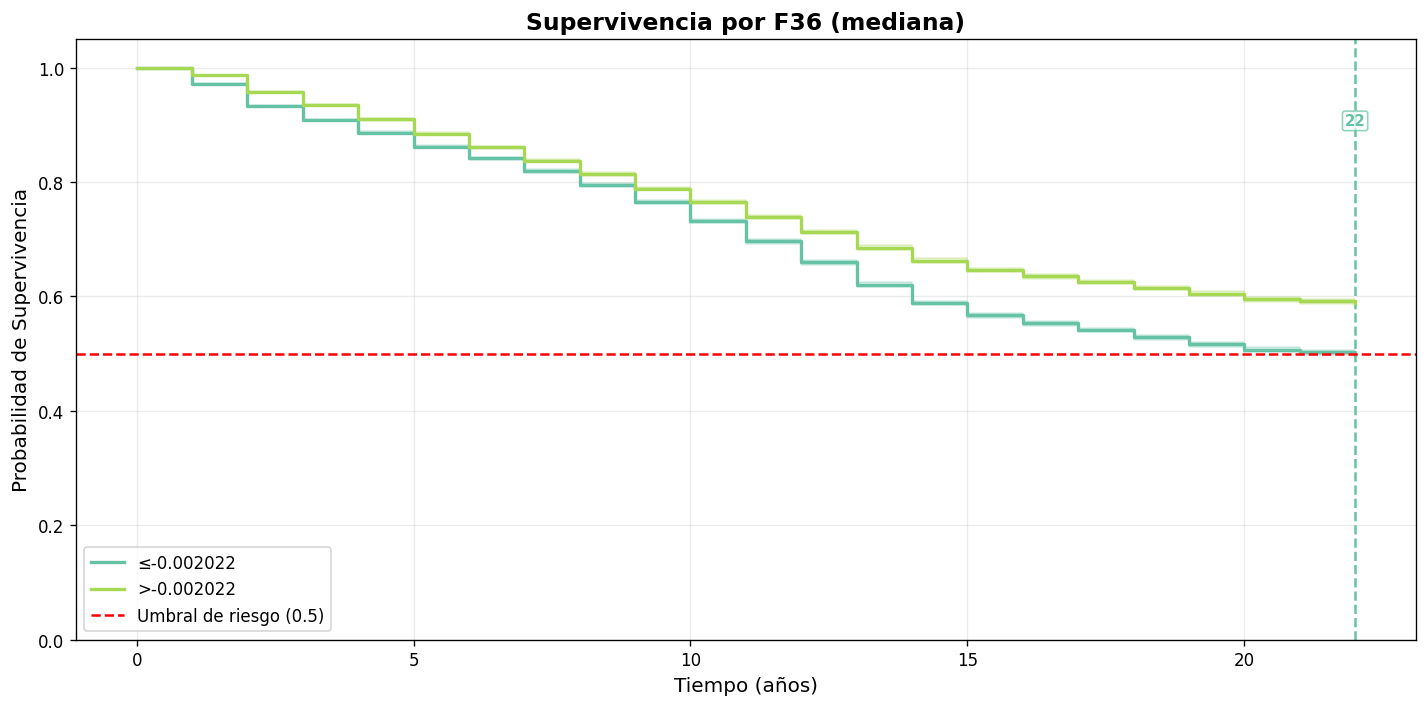

In [154]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F36 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.27 F37

In [155]:
groups = pd.cut(all_data['F37'], bins=[-np.inf, -0.0014787427148279, np.inf], labels=['≤-0.001479', '>-0.001479'], include_lowest=True)
present = [l for l in ['≤-0.001479', '>-0.001479'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F37')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F37
  ≤-0.001479                n=58,526  eventos=26,664  mediana=20.0
  >-0.001479                n=58,526  eventos=21,088  mediana=No alcanzada

Log-rank p = 1.11e-283


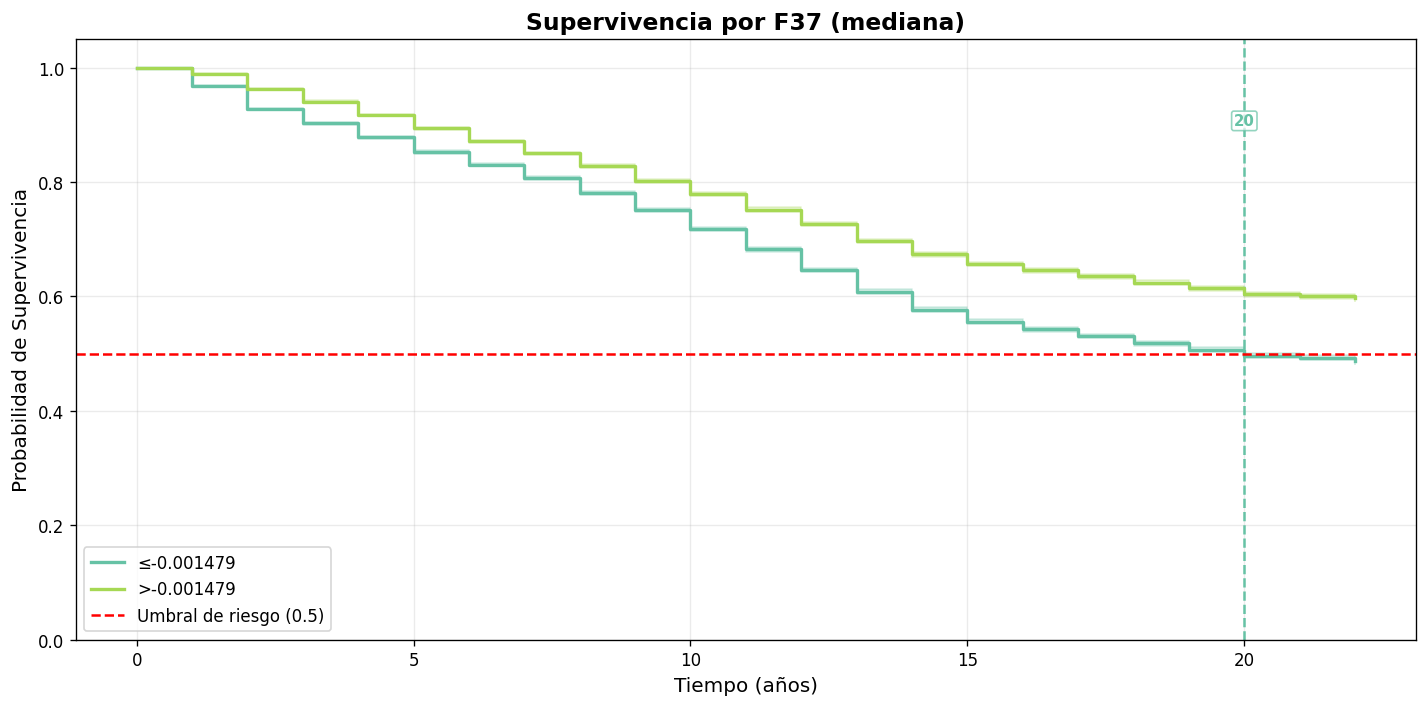

In [156]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F37 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.28 F38

In [157]:
groups = pd.cut(all_data['F38'], bins=[-np.inf, -0.00076277894089695, np.inf], labels=['≤-0.000763', '>-0.000763'], include_lowest=True)
present = [l for l in ['≤-0.000763', '>-0.000763'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F38')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F38
  ≤-0.000763                n=58,526  eventos=25,295  mediana=No alcanzada
  >-0.000763                n=58,526  eventos=22,457  mediana=No alcanzada

Log-rank p = 4.31e-74


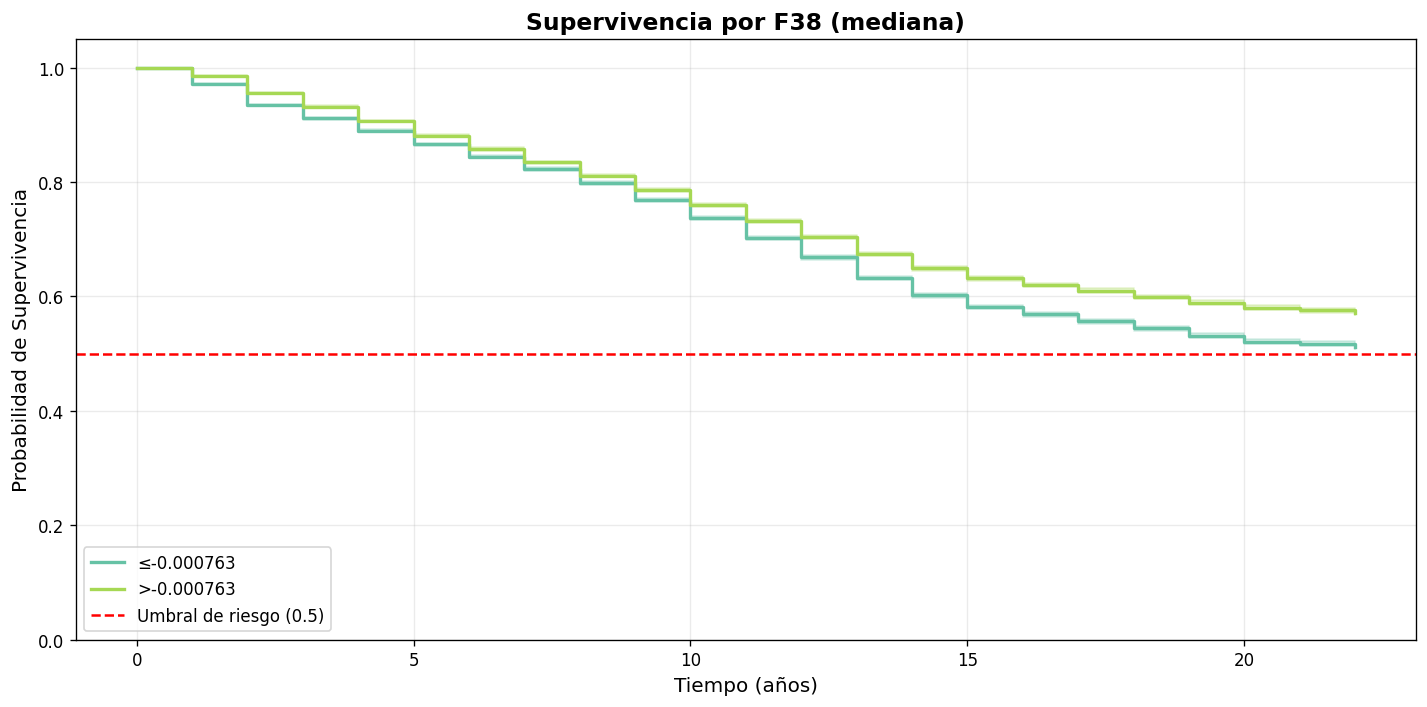

In [158]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F38 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.29 F39

In [159]:
groups = pd.cut(all_data['F39'], bins=[-np.inf, -0.00214891037079265, np.inf], labels=['≤-0.002149', '>-0.002149'], include_lowest=True)
present = [l for l in ['≤-0.002149', '>-0.002149'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F39')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F39
  ≤-0.002149                n=58,526  eventos=26,686  mediana=18.0
  >-0.002149                n=58,526  eventos=21,066  mediana=No alcanzada

Log-rank p = 0.00e+00


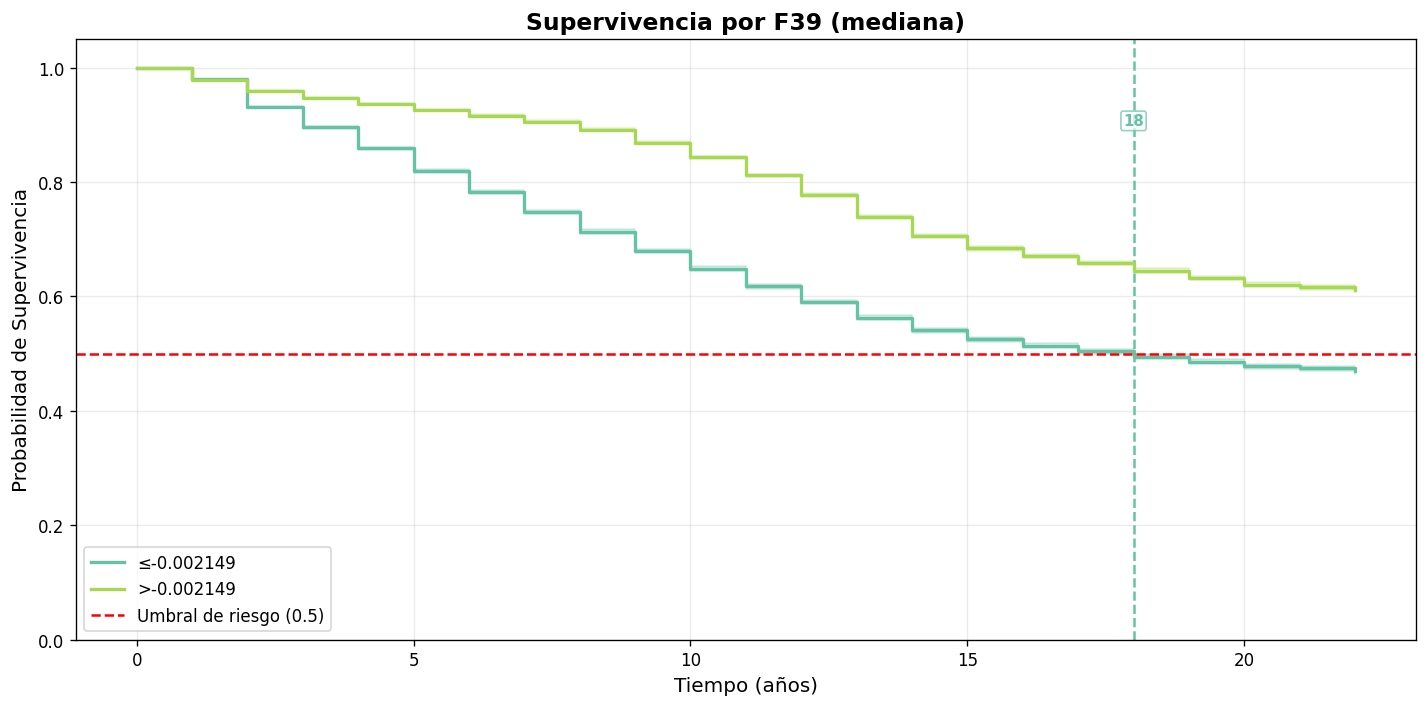

In [160]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F39 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.30 F40

In [161]:
groups = pd.cut(all_data['F40'], bins=[-np.inf, -0.00065503362352775, np.inf], labels=['≤-0.000655', '>-0.000655'], include_lowest=True)
present = [l for l in ['≤-0.000655', '>-0.000655'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F40')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F40
  ≤-0.000655                n=58,526  eventos=25,465  mediana=No alcanzada
  >-0.000655                n=58,526  eventos=22,287  mediana=No alcanzada

Log-rank p = 2.35e-96


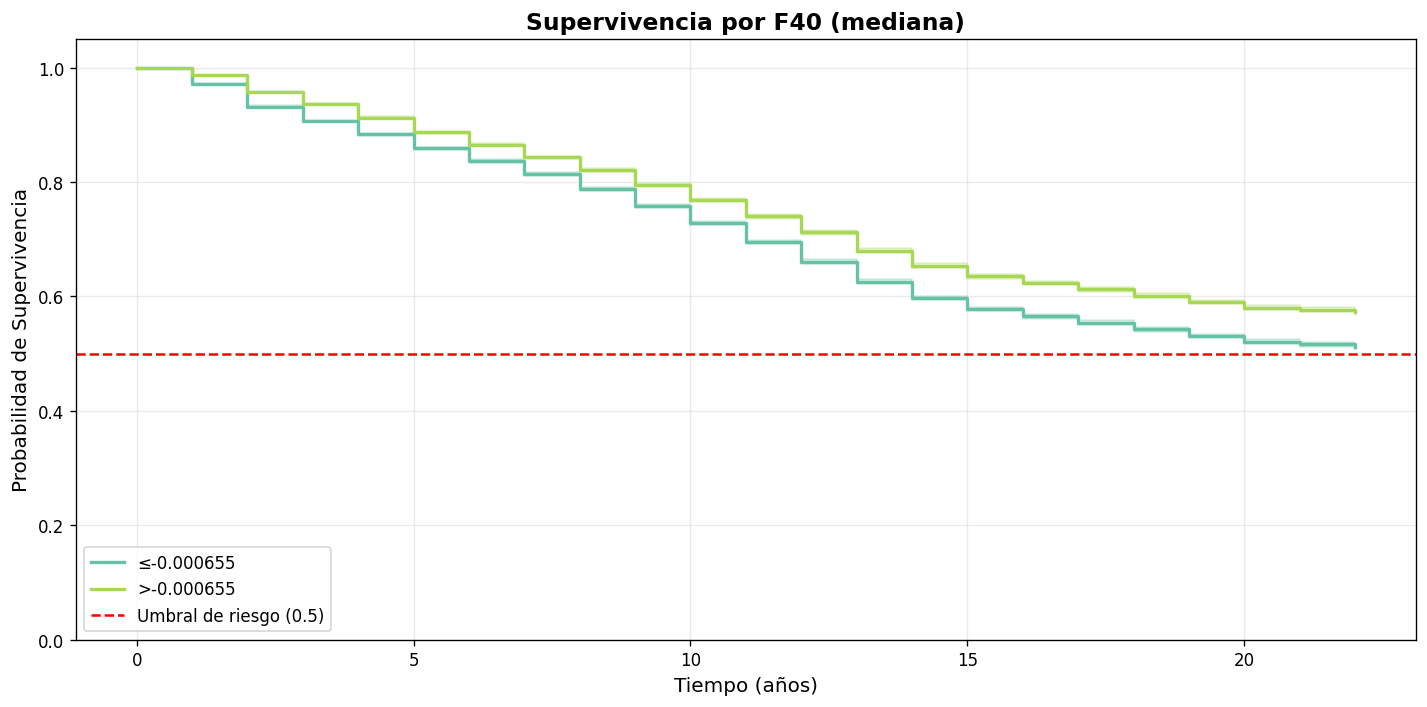

In [162]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F40 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.31 F41

In [163]:
groups = pd.cut(all_data['F41'], bins=[-np.inf, -0.00015348459964595, np.inf], labels=['≤-0.000153', '>-0.000153'], include_lowest=True)
present = [l for l in ['≤-0.000153', '>-0.000153'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F41')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F41
  ≤-0.000153                n=58,526  eventos=25,633  mediana=22.0
  >-0.000153                n=58,526  eventos=22,119  mediana=No alcanzada

Log-rank p = 2.29e-232


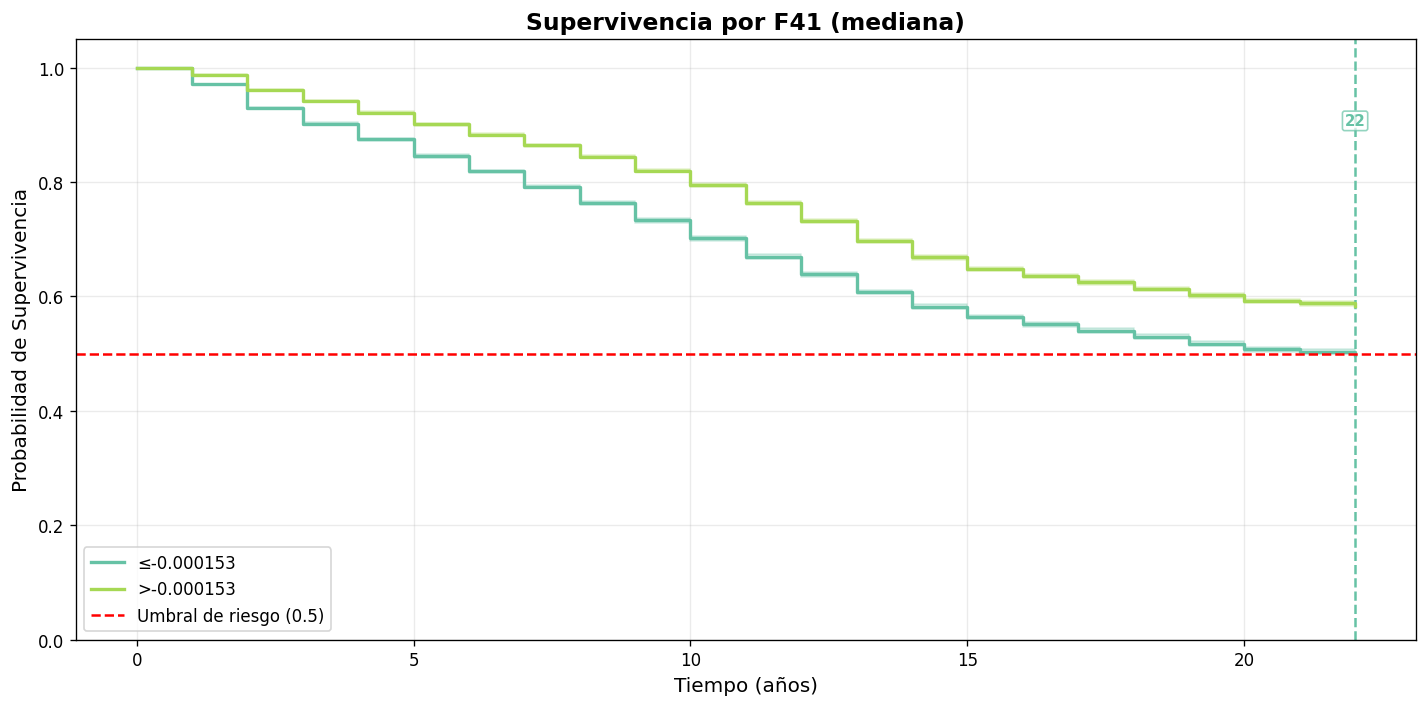

In [164]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F41 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.32 F42

In [165]:
groups = pd.cut(all_data['F42'], bins=[-np.inf, 0.00038551802504834995, np.inf], labels=['≤0.000386', '>0.000386'], include_lowest=True)
present = [l for l in ['≤0.000386', '>0.000386'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F42')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F42
  ≤0.000386                 n=58,526  eventos=21,324  mediana=No alcanzada
  >0.000386                 n=58,526  eventos=26,428  mediana=19.0

Log-rank p = 0.00e+00


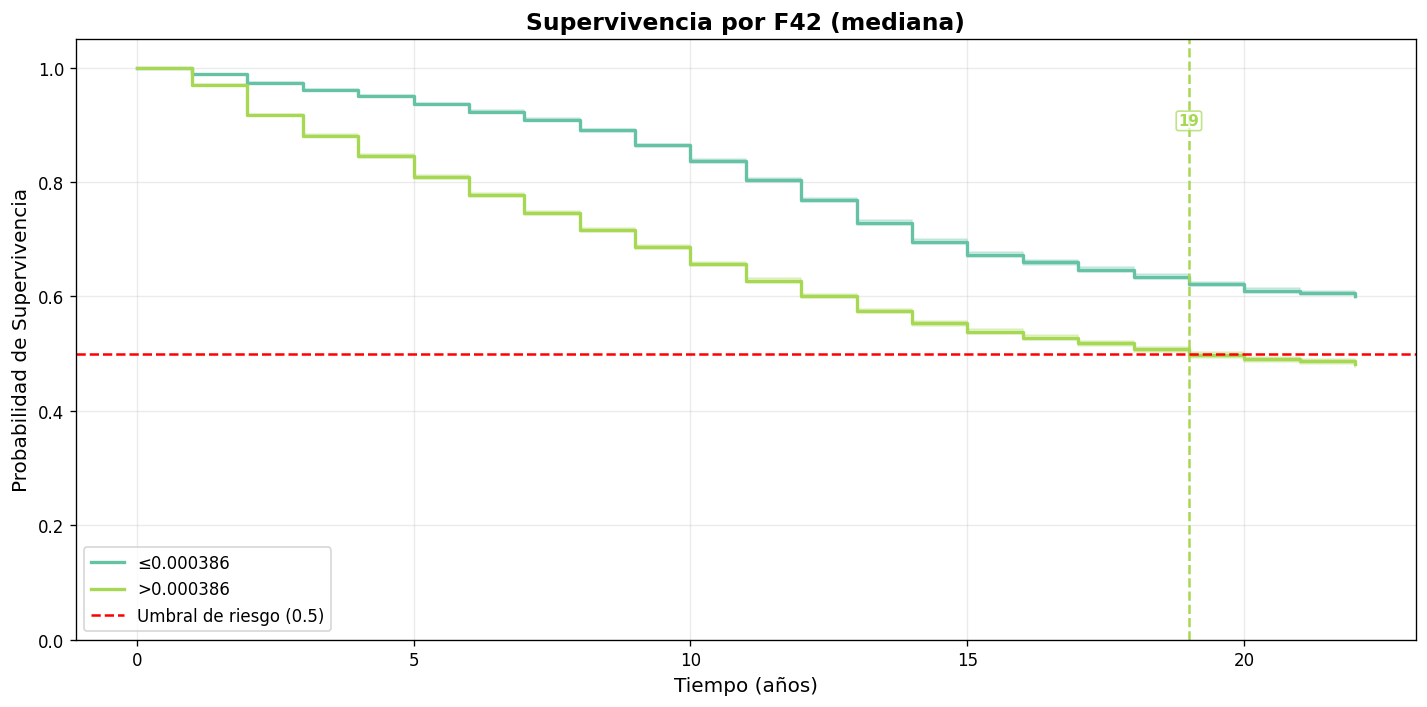

In [166]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F42 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


### 6.33 F43

In [167]:
groups = pd.cut(all_data['F43'], bins=[-np.inf, 0.00026346228277655, np.inf], labels=['≤0.000263', '>0.000263'], include_lowest=True)
present = [l for l in ['≤0.000263', '>0.000263'] if groups.eq(l).any()]
fitters = {}
for label in present:
    mask = groups == label
    kmf = sa.fit_km_safe(all_data.loc[mask,'Stop'], all_data.loc[mask,'Event'],
                         all_data.loc[mask,'Start'], label)
    if kmf: fitters[label] = kmf
print(f'Variable: F43')
for lbl, kmf in fitters.items():
    n  = int((groups==lbl).sum())
    ne = int(kmf.event_table['observed'].sum())
    md_ = getattr(kmf, 'median_survival_time_', None)
    ms = f'{md_:.1f}' if md_ is not None and np.isfinite(md_) else 'No alcanzada'
    print(f'  {lbl:25s} n={n:>6,}  eventos={ne:>5,}  mediana={ms}')
if len(fitters) >= 2:
    m = groups.isin(present)
    r = multivariate_logrank_test(all_data.loc[m,'Stop'], groups[m], all_data.loc[m,'Event'])
    print(f'\nLog-rank p = {r.p_value:.2e}')


Variable: F43
  ≤0.000263                 n=58,526  eventos=21,011  mediana=No alcanzada
  >0.000263                 n=58,526  eventos=26,741  mediana=20.0

Log-rank p = 0.00e+00


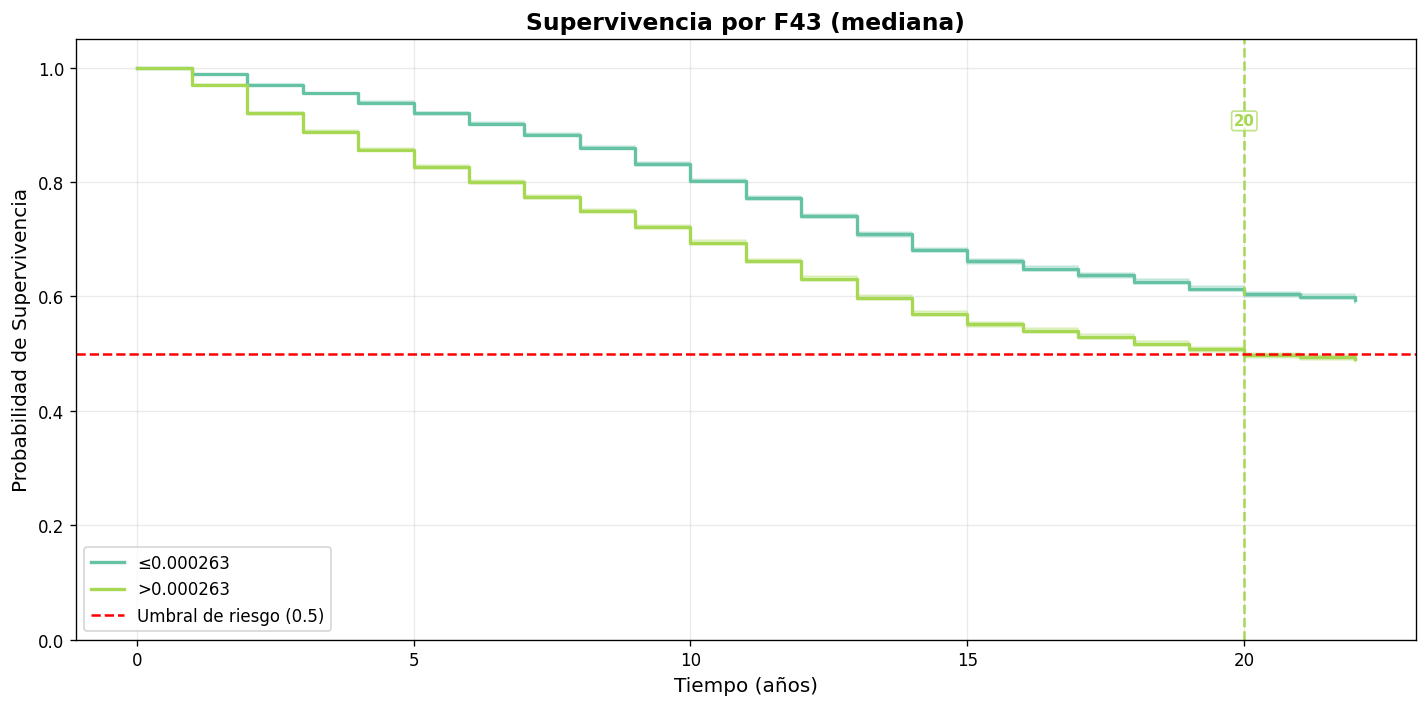

In [168]:
fig, ax = plt.subplots()
colors = plt.cm.Set2(np.linspace(0,1,max(len(fitters),3)))
for (nm, kmf), clr in zip(fitters.items(), colors):
    kmf.plot_survival_function(ax=ax, ci_show=True, linewidth=2, color=clr)
    sf = kmf.survival_function_; ms = sf.iloc[:,0] < 0.5
    if ms.any():
        tc = sf.index[ms.values.argmax()]
        ax.axvline(x=tc, color=clr, linestyle='--', linewidth=1.5)
        ax.text(tc, 0.92, f'{tc:.0f}', color=clr, fontsize=9, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor=clr, alpha=0.7))
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral de riesgo (0.5)')
ax.set_title(f'Supervivencia por F43 (mediana)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo (años)', fontsize=12); ax.set_ylabel('Probabilidad de Supervivencia', fontsize=12)
ax.grid(True, alpha=0.25); ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left'); plt.tight_layout(); plt.show()


## 7. Conclusiones

1. **Supervivencia global**: La función de Kaplan-Meier muestra una disminución progresiva de la probabilidad de supervivencia. El cruce del umbral S(t)=0.5 indica el año a partir del cual la mayoría de empresas han fracasado.

2. **Variables categóricas**: Se identifican diferencias significativas (log-rank) según sector, forma jurídica, tamaño, etc., lo que confirma su relevancia como factores de riesgo.

3. **Variables numéricas**: La segmentación por {SECTION_TITLE} revela que las variables financieras (rentabilidad, liquidez, endeudamiento) discriminan claramente entre grupos de alto y bajo riesgo.

4. **Perspectiva unificada**: El análisis combinado (train+test) proporciona una visión global del fenómeno, maximizando el tamaño muestral y la potencia estadística.

---
*Notebook generado a partir de `survival_analysis.py` — análisis combinado (train + test)*
